# Auto-Tuning Policy Framework — End-to-End Test

This notebook runs the full auto-tuning policy stack against real customer data to answer five questions:

| Phase | Question |
|-------|----------|
| 2b    | How much annual cost savings can the framework unlock? |
| 2c    | How many tuning cycles are needed per action (ramp length)? |
| 3     | At what rate do blocking rules fire, and which rules block the most value? |
| 4     | What is the false-positive rate of the duration regression detector? |
| 5     | What edge cases exist that could break the framework? |

**Data source:** `data/insights_with_recommendations_output.csv` (gitignored; run fetch notebook + add_recommendations.py) — one row per run × insight.
**Task identity:** logical task = `(app_id, task_name)`; `task_id` is a single run id.


## Cell Group 0 — Setup

In [1]:
import json
import sys
import math
import collections
import statistics
import warnings
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100

ROOT = Path.cwd()
if not (ROOT / "data" / "case_studies").is_dir() and (ROOT.parent / "data" / "case_studies").is_dir():
    ROOT = ROOT.parent

CSV_PATH = ROOT / "data" / "insights_with_recommendations_output.csv"
BACKEND_PATH = Path(os.environ.get("DEFINITY_BACKEND_ROOT", "../definity-app/backend")).resolve()
if str(BACKEND_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_PATH))


In [2]:
# Import tuning framework — wrapped in try/except to give a clear error if the path is wrong
try:
    from app.brain.insights.tuning import (
        build_tuning_plan,
        TuningConstraints,
        ActiveInsight,
        TaskRunMetrics,
        TaskProfile,
        TuningAction,
        TuningPlan,
        build_staircase_for_action,
        # autonomous loop
        create_knob_state,
        get_initial_next_value,
        process_run_outcome,
        RunOutcome,
        KnobTuningState,
        TaskTuningSession,
    )
    from app.brain.insights.tuning.run_metrics import compute_run_metrics
    from app.brain.insights.tuning.task_profile import compute_task_profile
    from app.brain.insights.tuning.blocking import (
        check_blocking,
        HEADROOM_BLOCK_THRESHOLD,
        VCORE_SATURATION_THRESHOLD,
        SKEW_BLOCK_THRESHOLD,
        GC_BLOCK_THRESHOLD,
    )
    from app.brain.insights.tuning.run_assessor import (
        assess_duration_regression,
        get_confirmation_status,
        CONFIRMATION_RUNS_REQUIRED,
    )
    from app.brain.insights.tuning.step import build_staircase, compute_next_value
    from app.brain.insights.tuning.knob_registry import KNOB_REGISTRY, KnobStepCap, registry_key_for_rec
    from app.brain.insights.recommendations import extract_recommendations
    print('Framework imports OK')
except ImportError as e:
    raise ImportError(
        f'Could not import tuning framework: {e}\n'
        f'Check that BACKEND_PATH is correct: {BACKEND_PATH}'
    ) from e


Framework imports OK


## Cell Group 1 — Load & Inspect

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Shape:', df.shape)

Shape: (19654, 83)


In [4]:
# Fill-rate table for key signal columns used by run_metrics / blocking rules
signal_cols = [
    'executor_heap_memory_allocated_gb',
    'executor_heap_memory_peak_gb',
    'executor_off_heap_memory_allocated_gb',
    'executor_off_heap_memory_peak_gb',
    'executors_jvm_gc_seconds',
    'executors_run_time_seconds',
    'executors_vcore_seconds_used',
    'executors_vcore_seconds_allocated',
    'task_idle_seconds',
    'task_skew_seconds',
    'task_duration_seconds',
    'executors_cpu_time_seconds',
    'disk_bytes_spilled',
    'total_io_bytes',
    'vcore_seconds_wasted_on_retries',
    'spark_shuffle_partitions',
    'is_dynamic_allocation',
    'spark_dynamic_alloc_min_executors',
    'insights_payload',
    'insight_usd_cost',
]

fill_data = []
for col in signal_cols:
    if col not in df.columns:
        fill_data.append({'column': col, 'non_null': 0, 'fill_rate': 0.0})
        continue
    non_null = df[col].notna().sum()
    fill_data.append({
        'column': col,
        'non_null': int(non_null),
        'fill_rate': round(non_null / len(df) * 100, 1),
    })

fill_df = pd.DataFrame(fill_data)
print('Signal column fill rates:')
print(fill_df.to_string(index=False))

Signal column fill rates:
                               column  non_null  fill_rate
    executor_heap_memory_allocated_gb     18938       96.4
         executor_heap_memory_peak_gb     18938       96.4
executor_off_heap_memory_allocated_gb     18938       96.4
     executor_off_heap_memory_peak_gb     18938       96.4
             executors_jvm_gc_seconds     18938       96.4
           executors_run_time_seconds     18940       96.4
         executors_vcore_seconds_used     18940       96.4
    executors_vcore_seconds_allocated     18937       96.4
                    task_idle_seconds     18463       93.9
                    task_skew_seconds     18938       96.4
                task_duration_seconds     19263       98.0
           executors_cpu_time_seconds     18938       96.4
                   disk_bytes_spilled     18938       96.4
                       total_io_bytes     18938       96.4
      vcore_seconds_wasted_on_retries     18938       96.4
             spark_shuffle_par

In [5]:
# Insight type distribution (excluding rows with no insight)
insight_counts = df['insight_type'].value_counts(dropna=False)
print('Insight type distribution:')
print(insight_counts.to_string())
print()
print(f'Total rows: {len(df)}')
print(f'Rows with insight_type set: {df["insight_type"].notna().sum() - (df["insight_type"] == "").sum()}')

Insight type distribution:
insight_type
NaN                                          15420
long_skew_time                                 907
long_idle_time                                 875
orphaned_machine_vcores                        691
over_provisioned_driver_cores                  681
task_retries_cost                              357
orphaned_node_resources                        291
executors_long_spill_time                      261
over_provisioned_executor_heap_memory           73
spark_task_retries_cost                         32
over_provisioned_executor_off_heap_memory       23
over_provisioned_machine_type                   23
over_provisioned_driver_heap_memory             10
executors_long_gc_time                           8
under_utilized_executors_cpu                     2

Total rows: 19654
Rows with insight_type set: 4234


## Cell Group 2 — Helper Functions (Phase 1 Prep)

These helpers bridge the CSV's single-underscore column aliases to the
double-underscore column names that the framework's `compute_run_metrics` and
`compute_task_profile` functions expect (those names match the DB
`task_enrichments` table).

In [6]:
def safe_float(v):
    """Convert a value to float, returning None for missing/empty/non-numeric values."""
    if v is None:
        return None
    if isinstance(v, float) and math.isnan(v):
        return None
    try:
        return float(v)
    except (ValueError, TypeError):
        return None


def safe_int(v):
    """Convert a value to int, returning None for missing/empty/non-numeric values."""
    f = safe_float(v)
    return int(f) if f is not None else None


def csv_row_to_enrichment(row):
    """
    Map a CSV row (pandas Series or dict) to the enrichment dict keyed by
    task_enrichments DB column names, as expected by compute_run_metrics() and
    compute_task_profile().

    Unit notes:
      - executors_jvm_gc_seconds / executors_run_time_seconds are stored in the
        CSV with a '_seconds' suffix alias but the actual values are milliseconds.
        run_metrics.py works in milliseconds, so we pass the raw values as-is.
      - executors_cpu_time_seconds likewise stores nanoseconds; run_metrics.py
        handles the ns->ms conversion internally.
      - task_idle_seconds / task_skew_seconds are clamped to >= 0 because
        earlier pipeline versions could produce small negative values.
    """
    def _v(col):
        """Get a scalar value from the row regardless of whether it's a Series or dict."""
        val = row[col] if isinstance(row, dict) else row.get(col)
        if val is None:
            return None
        if isinstance(val, float) and math.isnan(val):
            return None
        # pandas NaN / empty string -> None
        s = str(val).strip()
        if s in ('', 'nan', 'None', 'NaN'):
            return None
        return val

    def _fn(col):
        """Float or None."""
        return safe_float(_v(col))

    def _clamp_non_neg(col):
        """Float >= 0.0, or None."""
        v = _fn(col)
        return max(0.0, v) if v is not None else None

    def _bool_col(col):
        """Return Python bool or None for boolean-ish columns."""
        v = _v(col)
        if v is None:
            return None
        if isinstance(v, bool):
            return v
        s = str(v).strip().lower()
        if s in ('true', '1', 'yes'):
            return True
        if s in ('false', '0', 'no'):
            return False
        return None

    return {
        # --- heap memory (GB) ---
        'executor__memory_heap__allocated':     _fn('executor_heap_memory_allocated_gb'),
        'executor__memory_heap__max_used':      _fn('executor_heap_memory_peak_gb'),
        # --- off-heap memory (GB) ---
        'executor__memory_off_heap__allocated': _fn('executor_off_heap_memory_allocated_gb'),
        'executor__memory_off_heap__max_used':  _fn('executor_off_heap_memory_peak_gb'),
        # --- GC / run time (ms — column alias says 'seconds' but values are ms) ---
        'executors__jvm_gc_time':               _fn('executors_jvm_gc_seconds'),
        'executors__run_time__used':            _fn('executors_run_time_seconds'),
        # --- vcore time (same ms units) ---
        'executors__vcore_time__used':          _fn('executors_vcore_seconds_used'),
        'executors__vcore_time__allocated':     _fn('executors_vcore_seconds_allocated'),
        # --- task timing (ms — aliased as 'seconds') ---
        #     Negative idle/skew clamped to 0 (pipeline artefact)
        'task__idle_time':                      _clamp_non_neg('task_idle_seconds'),
        'task__skew_time':                      _clamp_non_neg('task_skew_seconds'),
        'task__duration':                       _fn('task_duration_seconds'),
        # --- CPU time (nanoseconds — run_metrics.py divides by 1e6 internally) ---
        'executors__cpu_time__used':            _fn('executors_cpu_time_seconds'),
        # --- spill / IO (bytes) ---
        'task__disk_bytes_spilled':             _fn('disk_bytes_spilled'),
        'task__total_io_bytes':                 _fn('total_io_bytes'),
        # --- retried task waste (ms) ---
        'executors__used_vcore_time_of_retried_tasks': _fn('vcore_seconds_wasted_on_retries'),
        # --- config params ---
        'task__shuffle_partitions__param':      str(_v('spark_shuffle_partitions')) if _v('spark_shuffle_partitions') is not None else None,
        'task__dynamic_is_allocation_enabled__param': _bool_col('is_dynamic_allocation'),
        # --- executor count params (needed by long_idle_time extractor) ---
        'task__executors_dynamic_allocation_max_executors__param':
            safe_int(_v('spark_dynamic_alloc_max_executors')),
        'task__executors_dynamic_allocation_min_executors__param':
            safe_int(_v('spark_dynamic_alloc_min_executors')),
        'task__executor_instances__param':
            safe_int(_v('spark_executor_instances')),
        # --- cluster sizing ---
        'cluster_min_workers':   safe_int(_v('cluster_min_workers')),
        'cluster_max_workers':   safe_int(_v('cluster_max_workers')),
        'cluster_workers':       safe_int(_v('cluster_workers')),
    }

# Logical task identity — one scheduled job = (app_id, task_name).
# task_id is a single run id; many task_ids can belong to one logical task.
TASK_KEY = ["app_id", "task_name"]


def task_key_from_row(row) -> tuple:
    '''Return (app_id, task_name) for a CSV row.'''
    if isinstance(row, dict):
        return (row["app_id"], row["task_name"])
    return (row["app_id"], row["task_name"])


def task_key_label(task_key: tuple) -> str:
    app_id, task_name = task_key
    return f"app_id={app_id} task_name={task_name!r}"


def latest_insight_rows_per_task(df: pd.DataFrame) -> pd.DataFrame:
    '''One row per (app_id, task_name, insight_type) - latest start_time wins.'''
    tmp = df.copy()
    tmp["_start_ts"] = pd.to_datetime(tmp["start_time"], utc=True, errors="coerce")
    return (
        tmp.sort_values("_start_ts")
        .groupby(TASK_KEY + ["insight_type"], as_index=False)
        .tail(1)
        .drop(columns=["_start_ts"])
    )


def latest_run_row_per_task(df: pd.DataFrame) -> pd.DataFrame:
    '''Latest run snapshot per logical task.'''
    tmp = df.copy()
    tmp["_start_ts"] = pd.to_datetime(tmp["start_time"], utc=True, errors="coerce")
    return (
        tmp.sort_values("_start_ts")
        .groupby(TASK_KEY, as_index=False)
        .tail(1)
        .drop(columns=["_start_ts"])
    )


def task_meta_dict(task_key: tuple, prepared_tasks: dict) -> dict:
    '''Common identity columns for analysis DataFrames.'''
    data = prepared_tasks.get(task_key, {})
    row = data.get("row")
    return {
        "app_id": task_key[0],
        "task_name": task_key[1],
        "task_id": row.get("task_id") if row is not None else None,
    }


print('Helper functions defined.')


Helper functions defined.


In [7]:
def build_task_profile(row):
    """Build a TaskProfile from a CSV row via the enrichment dict."""
    enrichment = csv_row_to_enrichment(row)
    return compute_task_profile(enrichment)


def build_run_metrics(row):
    """Build a TaskRunMetrics from a CSV row via the enrichment dict."""
    enrichment = csv_row_to_enrichment(row)
    return compute_run_metrics(enrichment)


def parse_insights_payload(row):
    """Parse the insights_payload JSON string from a CSV row.

    Returns a dict if the payload is a valid JSON object, otherwise None.
    Handles empty strings, 'None', bare null, etc. gracefully.
    """
    raw = row['insights_payload'] if isinstance(row, dict) else row.get('insights_payload')
    if raw is None or (isinstance(raw, float) and math.isnan(raw)):
        return None
    s = str(raw).strip()
    if s in ('', 'None', 'nan', 'null'):
        return None
    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, dict) else None
    except (json.JSONDecodeError, ValueError):
        return None


def build_active_insight(row):
    """Build an ActiveInsight from a single CSV row.

    Returns None if the row has no usable insight_type.
    """
    insight_type = row['insight_type'] if isinstance(row, dict) else row.get('insight_type', '')
    if not insight_type or (isinstance(insight_type, float) and math.isnan(insight_type)):
        return None
    insight_type = str(insight_type).strip()
    if not insight_type:
        return None
    payload = parse_insights_payload(row)
    usd_cost = safe_float(row['insight_usd_cost'] if isinstance(row, dict) else row.get('insight_usd_cost'))
    return ActiveInsight(
        insight_type=insight_type,
        payload=payload,
        usd_cost_annual=usd_cost,
    )


print('Helper functions defined.')

Helper functions defined.


## Cell Group 3 — Phase 1: Build Per-Task Inputs

For each unique logical task (`app_id` + `task_name`), collect active insights
(latest snapshot per `insight_type`) and build `TaskRunMetrics` / `TaskProfile`
from the latest run row.


In [8]:
# Filter to rows that have a non-empty insight_type AND a non-null insights_payload
df_insights = df[
    df['insight_type'].notna() &
    (df['insight_type'].str.strip() != '') &
    df['insights_payload'].notna() &
    (df['insights_payload'].str.strip() != '')
].copy()

print(f'Rows with insight_type AND insights_payload: {len(df_insights)} / {len(df)}')
print(f'Unique logical tasks (app_id + task_name): {df_insights.groupby(TASK_KEY).ngroups}')
print(f'Unique run ids (task_id): {df_insights["task_id"].nunique()}')


Rows with insight_type AND insights_payload: 4234 / 19654
Unique logical tasks (app_id + task_name): 311
Unique run ids (task_id): 2923


In [9]:
# Group by logical task (app_id + task_name).  For each task:
#   - Take the row with the latest start_time as the 'current state' for metrics/profile
#   - Collect one ActiveInsight per insight_type (latest snapshot per type)
#
# Note: the CSV has one row per (task_id, insight_type).  Multiple task_ids can
# share the same (app_id, task_name) across runs — we merge those into one task.

prepared_tasks = {}  # (app_id, task_name) -> {...}
skipped_no_insight = 0
null_signal_counts = collections.Counter()

df_insights_latest = latest_insight_rows_per_task(df_insights)

for task_key, group in df_insights_latest.groupby(TASK_KEY, sort=False):
    latest_row = group.sort_values('start_time', ascending=False).iloc[0]

    insights = []
    for _, row in group.iterrows():
        ai = build_active_insight(row)
        if ai is not None:
            insights.append(ai)

    if not insights:
        skipped_no_insight += 1
        continue

    metrics = build_run_metrics(latest_row)
    profile = build_task_profile(latest_row)

    for field_name, value in [
        ('memory_headroom', metrics.memory_headroom),
        ('gc_pressure',     metrics.gc_pressure),
        ('vcore_utilization', metrics.vcore_utilization),
        ('idle_ratio',      metrics.idle_ratio),
        ('skew_ratio',      metrics.skew_ratio),
        ('cpu_efficiency',  metrics.cpu_efficiency),
        ('spill_ratio',     metrics.spill_ratio),
    ]:
        if value is None:
            null_signal_counts[field_name] += 1

    prepared_tasks[task_key] = {
        'insights': insights,
        'metrics': metrics,
        'profile': profile,
        'row': latest_row,
        'app_id': task_key[0],
        'task_name': task_key[1],
        'task_id': latest_row['task_id'],
    }

print(f'Tasks fully prepared: {len(prepared_tasks)}')
print(f'Tasks skipped (no usable insight): {skipped_no_insight}')
print()
print('Null signal counts per task (tasks where signal could not be computed):')
for signal, count in sorted(null_signal_counts.items(), key=lambda x: -x[1]):
    pct = 100.0 * count / len(prepared_tasks) if prepared_tasks else 0
    print(f'  {signal:<22}: {count:>5} / {len(prepared_tasks)} ({pct:.1f}%)')


Tasks fully prepared: 311
Tasks skipped (no usable insight): 0

Null signal counts per task (tasks where signal could not be computed):
  spill_ratio           :   237 / 311 (76.2%)
  gc_pressure           :    55 / 311 (17.7%)
  cpu_efficiency        :    55 / 311 (17.7%)
  idle_ratio            :    43 / 311 (13.8%)
  memory_headroom       :    18 / 311 (5.8%)
  vcore_utilization     :    18 / 311 (5.8%)
  skew_ratio            :    18 / 311 (5.8%)


## Cell Group 4 — Phase 2a: Build Tuning Plans

For each prepared task, call `build_tuning_plan()` with default constraints
(`TuningConstraints()`).  The plan partitions each task's recommendations into
unblocked `actions` and `blocked_actions`.

In [10]:
default_constraints = TuningConstraints()  # standard preset: 10% duration tolerance

plans = {}  # (app_id, task_name) -> TuningPlan

for task_key, task_data in prepared_tasks.items():
    plan = build_tuning_plan(
        active_insights=task_data['insights'],
        constraints=default_constraints,
        run_metrics=task_data['metrics'],
        task_profile=task_data['profile'],
    )
    plans[task_key] = plan

total_actions = sum(len(p.actions) for p in plans.values())
total_blocked = sum(len(p.blocked_actions) for p in plans.values())
tasks_with_action = sum(1 for p in plans.values() if p.actions)
tasks_all_blocked = sum(
    1 for p in plans.values()
    if not p.actions and p.blocked_actions
)
tasks_no_actions = sum(
    1 for p in plans.values()
    if not p.actions and not p.blocked_actions
)

print(f'Tasks processed:                {len(plans)}')
print(f'Total unblocked actions:        {total_actions}')
print(f'Total blocked actions:          {total_blocked}')
print(f'Tasks with >=1 unblocked action:{tasks_with_action}')
print(f'Tasks fully blocked:            {tasks_all_blocked}')
print(f'Tasks with no actions at all:   {tasks_no_actions}')
if total_actions + total_blocked > 0:
    block_rate = 100.0 * total_blocked / (total_actions + total_blocked)
    print(f'Overall block rate:             {block_rate:.1f}%')


Tasks processed:                311
Total unblocked actions:        265
Total blocked actions:          10
Tasks with >=1 unblocked action:225
Tasks fully blocked:            7
Tasks with no actions at all:   79
Overall block rate:             3.6%


In [11]:
# Pick any logical task with unblocked actions for quick inspection
_demo_key = next((k for k, p in plans.items() if p.actions), None)
if _demo_key:
    _demo = prepared_tasks[_demo_key]
    print(f'Inspecting {task_key_label(_demo_key)}  task_id={_demo["task_id"]} — {len(plans[_demo_key].actions)} unblocked action(s)')
    plans[_demo_key].actions
else:
    print('No tasks with unblocked actions found.')


Inspecting app_id=21850 task_name='setup_job_parameters'  task_id=2034416 — 1 unblocked action(s)


## Phase 2a-b — Which knobs get tuned?

**Question:** Which Spark / cluster parameters appear most often in tuning plans?

Each **unblocked action** is counted separately — a task with three knobs contributes three rows.
Blocked actions are summarized separately at the end.

Unblocked actions (total knob-tuning opportunities): 265
Tasks with >=1 unblocked action:                    225
Actions per task — mean: 1.18  median: 1  max: 3
Tasks with 2+ knobs in the same plan:               34

## Knob frequency (unblocked actions)



,knob,action_count,task_count,total_full_savings_usd,median_full_savings_usd,pct_of_actions,pct_of_tasks
0,clusterMaxWorkers,86,86,0.000000,NaN,32.5,38.2
1,change_instance_type (driver/worker SKU),70,69,141735.696546,412.298822,26.4,30.7
2,spark.sql.shuffle.partitions,70,66,77648.500646,1570.758391,26.4,29.3
3,spark.executor.cores,17,17,90070.781663,2114.234438,6.4,7.6
4,spark.executor.memory,8,8,3312.262797,409.645531,3.0,3.6
5,spark.driver.cores,6,6,1399.232426,258.271332,2.3,2.7
6,spark.driver.memory,2,2,3891.905071,1945.952536,0.8,0.9
7,spark.executor.instances,2,2,0.000000,NaN,0.8,0.9
8,spark.executor.memoryOverhead,2,2,741.494166,370.747083,0.8,0.9
9,clusterWorkers,1,1,0.000000,NaN,0.4,0.4


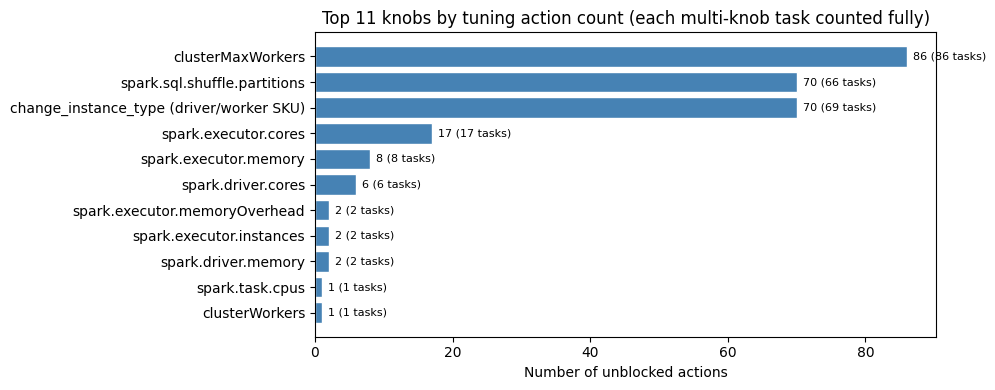


## Spark `config_key` only (subset)



,config_key,action_count,task_count,pct_of_spark_actions
0,clusterMaxWorkers,86,86,44.1
1,spark.sql.shuffle.partitions,70,66,35.9
2,spark.executor.cores,17,17,8.7
3,spark.executor.memory,8,8,4.1
4,spark.driver.cores,6,6,3.1
5,spark.driver.memory,2,2,1.0
6,spark.executor.instances,2,2,1.0
7,spark.executor.memoryOverhead,2,2,1.0
8,clusterWorkers,1,1,0.5
9,spark.task.cpus,1,1,0.5



## Knob × insight_type



,knob,insight_type,action_count
1,change_instance_type (driver/worker SKU),over_provisioned_driver_cores,65
0,change_instance_type (driver/worker SKU),executors_long_spill_time,3
2,change_instance_type (driver/worker SKU),over_provisioned_machine_type,2
3,clusterMaxWorkers,long_idle_time,86
4,clusterWorkers,long_idle_time,1
5,spark.driver.cores,over_provisioned_driver_cores,6
6,spark.driver.memory,over_provisioned_driver_heap_memory,2
7,spark.executor.cores,orphaned_machine_vcores,17
8,spark.executor.instances,long_idle_time,2
9,spark.executor.memory,over_provisioned_executor_heap_memory,8



## Blocked actions by knob (10 total)



,knob,action_count,task_count
0,clusterMaxWorkers,7,7
1,spark.sql.shuffle.partitions,2,2
2,spark.driver.memory,1,1


In [12]:
def _action_knob_label(action: TuningAction) -> str:
    """Stable display name for grouping (config_key or instance-type action)."""
    if action.config_key:
        return action.config_key
    if action.action == "change_instance_type":
        return "change_instance_type (driver/worker SKU)"
    return action.action or "(unknown)"


def build_knob_frequency_rows(plans_dict, *, include_blocked: bool = False) -> pd.DataFrame:
    """One row per tuning action (unblocked by default)."""
    rows: list[dict] = []
    for task_key, plan in plans_dict.items():
        action_lists = [("unblocked", plan.actions)]
        if include_blocked:
            action_lists.append(("blocked", plan.blocked_actions))
        for status, actions in action_lists:
            for rank, action in enumerate(actions, start=1):
                rows.append({
                    **task_meta_dict(task_key, prepared_tasks),
                    "status": status,
                    "priority_rank": rank,
                    "knob": _action_knob_label(action),
                    "config_key": action.config_key,
                    "action_type": action.action,
                    "insight_type": action.insight_type,
                    "current_value": action.current_value,
                    "target_value": action.target_value,
                    "full_savings_usd_annual": action.cost_savings_usd_annual,
                    "step_savings_usd_annual": action.step_cost_savings_usd(),
                })
    return pd.DataFrame(rows)


knob_actions_df = build_knob_frequency_rows(plans, include_blocked=False)
knob_actions_df["_task_key"] = list(zip(knob_actions_df["app_id"], knob_actions_df["task_name"]))
knob_blocked_df = build_knob_frequency_rows(plans, include_blocked=True)
knob_blocked_df = knob_blocked_df[knob_blocked_df["status"] == "blocked"]
knob_blocked_df["_task_key"] = list(zip(knob_blocked_df["app_id"], knob_blocked_df["task_name"]))

if len(knob_actions_df) == 0:
    print("No unblocked actions in plans — run the plans cell above first.")
else:
    n_tasks_with_actions = knob_actions_df.groupby(TASK_KEY).ngroups
    n_actions = len(knob_actions_df)
    knobs_per_task = knob_actions_df.groupby(TASK_KEY).size()

    print(f"Unblocked actions (total knob-tuning opportunities): {n_actions}")
    print(f"Tasks with >=1 unblocked action:                    {n_tasks_with_actions}")
    print(f"Actions per task — mean: {knobs_per_task.mean():.2f}  "
          f"median: {knobs_per_task.median():.0f}  max: {knobs_per_task.max()}")
    print(f"Tasks with 2+ knobs in the same plan:               {(knobs_per_task >= 2).sum()}")
    print()

    # --- By knob (every action counted) ---
    by_knob = (
        knob_actions_df.groupby("knob", dropna=False)
        .agg(
            action_count=("_task_key", "size"),
            task_count=("_task_key", "nunique"),
            total_full_savings_usd=("full_savings_usd_annual", lambda s: s.fillna(0).sum()),
            median_full_savings_usd=("full_savings_usd_annual", "median"),
        )
        .sort_values("action_count", ascending=False)
    )
    by_knob["pct_of_actions"] = (100.0 * by_knob["action_count"] / n_actions).round(1)
    by_knob["pct_of_tasks"] = (100.0 * by_knob["task_count"] / n_tasks_with_actions).round(1)

    print("## Knob frequency (unblocked actions)\n")
    display(by_knob.reset_index())

    # --- Chart: action count by knob ---
    top_n = min(20, len(by_knob))
    plot_df = by_knob.head(top_n).sort_values("action_count")
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * top_n)))
    ax.barh(plot_df.index, plot_df["action_count"], color="steelblue", edgecolor="white")
    ax.set_xlabel("Number of unblocked actions")
    ax.set_title(f"Top {top_n} knobs by tuning action count (each multi-knob task counted fully)")
    for i, (cnt, tcnt) in enumerate(zip(plot_df["action_count"], plot_df["task_count"])):
        ax.text(cnt + max(plot_df["action_count"]) * 0.01, i, f"{int(cnt)} ({int(tcnt)} tasks)", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- Spark config keys only (exclude instance-type pseudo-knobs) ---
    spark_only = knob_actions_df[knob_actions_df["config_key"].notna()].copy()
    if len(spark_only):
        by_spark = (
            spark_only.groupby("config_key")
            .agg(action_count=("_task_key", "size"), task_count=("_task_key", "nunique"))
            .sort_values("action_count", ascending=False)
        )
        by_spark["pct_of_spark_actions"] = (
            100.0 * by_spark["action_count"] / len(spark_only)
        ).round(1)
        print("\n## Spark `config_key` only (subset)\n")
        display(by_spark.reset_index())

    # --- Knob × insight_type (which insights drive each knob) ---
    knob_insight = (
        knob_actions_df.groupby(["knob", "insight_type"])
        .size()
        .reset_index(name="action_count")
        .sort_values(["knob", "action_count"], ascending=[True, False])
    )
    print("\n## Knob × insight_type\n")
    display(knob_insight.head(40))

    if len(knob_blocked_df):
        blocked_by_knob = (
            knob_blocked_df.groupby("knob")
            .agg(action_count=("_task_key", "size"), task_count=("_task_key", "nunique"))
            .sort_values("action_count", ascending=False)
        )
        print(f"\n## Blocked actions by knob ({len(knob_blocked_df)} total)\n")
        display(blocked_by_knob.reset_index())


## Cell Group 5 — Phase 2b: Q1 — Cost Savings

**Business question:** How much annual cost savings can the framework unlock,
and how does that break down by insight type?

Two saving measures are computed:
- `full_savings`: full annual savings if target is reached (`cost_savings_usd_annual`)
- `step_savings`: savings realised by the *first step only* (`step_cost_savings_usd()`)

In [13]:
savings_rows = []

for task_key, plan in plans.items():
    meta = task_meta_dict(task_key, prepared_tasks)
    for action in plan.actions:
        full_s = action.cost_savings_usd_annual or 0.0
        step_s = action.step_cost_savings_usd() or 0.0
        savings_rows.append({
            **meta,
            'insight_type': action.insight_type,
            'full_savings': full_s,
            'step_savings': step_s,
        })

savings_df = pd.DataFrame(savings_rows)

task_savings = savings_df.groupby(TASK_KEY)['full_savings'].sum()

if len(task_savings) == 0:
    print('No unblocked actions with cost savings data found.')
else:
    nonzero = task_savings[task_savings > 0]
    print(f'Tasks with unblocked actions:         {len(task_savings)}')
    print(f'Tasks with positive annual savings:    {len(nonzero)}')
    print(f'Total annual savings (all tasks):      ${task_savings.sum():,.0f}')
    print(f'Median annual savings per task:        ${task_savings.median():,.0f}')
    print(f'p25 / p75:                             ${task_savings.quantile(0.25):,.0f} / ${task_savings.quantile(0.75):,.0f}')
    print(f'p90:                                   ${task_savings.quantile(0.90):,.0f}')

    print()
    total_step = savings_df.groupby(TASK_KEY)['step_savings'].sum()
    print(f'Total first-step savings (all tasks):  ${total_step.sum():,.0f}')
    capture_pct = 100.0 * total_step.sum() / task_savings.sum() if task_savings.sum() else 0
    print(f'First-step captures {capture_pct:.1f}% of full savings')


Tasks with unblocked actions:         225
Tasks with positive annual savings:    117
Total annual savings (all tasks):      $389,317
Median annual savings per task:        $118
p25 / p75:                             $0 / $945
p90:                                   $4,096

Total first-step savings (all tasks):  $206,414
First-step captures 53.0% of full savings


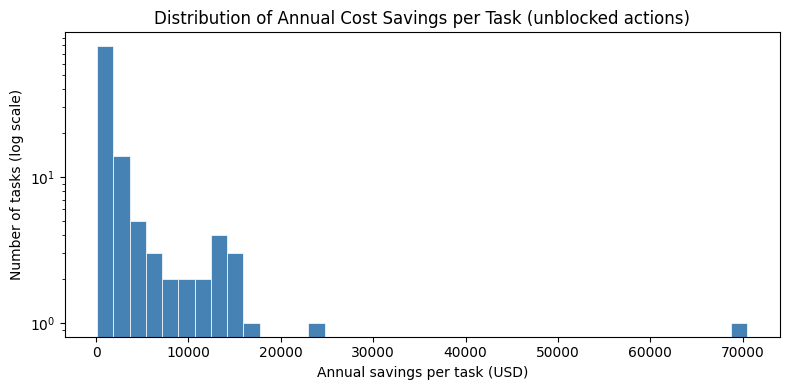

In [14]:
# Histogram of annual savings per task (log scale)
if len(task_savings) > 0 and task_savings.max() > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    # Only plot tasks with savings > $0
    pos_savings = task_savings[task_savings > 0]
    ax.hist(pos_savings, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_yscale('log')
    ax.set_xlabel('Annual savings per task (USD)')
    ax.set_ylabel('Number of tasks (log scale)')
    ax.set_title('Distribution of Annual Cost Savings per Task (unblocked actions)')
    plt.tight_layout()
    plt.show()
else:
    print('No positive savings to plot.')

In [15]:
from IPython.display import display

# Self-contained imports (safe if setup cell was run before KnobStepCap was added)
from app.brain.insights.tuning.knob_registry import KnobStepCap, KNOB_REGISTRY, registry_key_for_rec
from app.brain.insights.tuning.step import compute_next_value

DEFAULT_KNOB_CAP = KnobStepCap(pct_cap=0.20, abs_cap=5)


def _knob_label(action: TuningAction) -> str:
    if action.config_key:
        return action.config_key
    if action.action == "change_instance_type":
        return "instance_type (driver/worker)"
    return action.action or "?"


def _action_registry_cap(action: TuningAction) -> KnobStepCap:
    if action.config_key:
        reg_key = registry_key_for_rec({"config_key": action.config_key, "action": action.action})
    else:
        reg_key = registry_key_for_rec({"action": action.action})
    return KNOB_REGISTRY.get(reg_key, DEFAULT_KNOB_CAP)


def _full_ramp_values(action: TuningAction, constraints: TuningConstraints) -> list:
    """current → … → target (values at each tuning step for one knob)."""
    path = list(build_staircase_for_action(action, constraints))
    values = [action.current_value]
    values.extend(path)
    if values[-1] != action.target_value:
        values.append(action.target_value)
    return values


def _incremental_step_savings(
    action: TuningAction,
    from_value,
    to_value,
) -> float | None:
    """$ annual savings for moving one step along the ramp (linear in knob delta)."""
    if action.cost_savings_usd_annual is None:
        return None
    if not all(isinstance(v, (int, float)) for v in (action.current_value, action.target_value, from_value, to_value)):
        return None
    total = abs(action.current_value - action.target_value)
    if total == 0:
        return 0.0
    return round(action.cost_savings_usd_annual * abs(from_value - to_value) / total)


def _step_priority_score(action: TuningAction, from_value, to_value) -> float:
    """Comparable score for one candidate move (action priority × step savings share)."""
    base = action.priority_score
    step_save = _incremental_step_savings(action, from_value, to_value)
    if (
        step_save is not None
        and action.cost_savings_usd_annual
        and action.cost_savings_usd_annual > 0
    ):
        return round(base * step_save / action.cost_savings_usd_annual, 6)
    return base


def _priority_explanation(action: TuningAction, rank: int) -> str:
    parts = [f"rank #{rank}"]
    if action.cost_savings_usd_annual is not None and action.cost_savings_usd_annual > 0:
        parts.append(f"priority_score={action.priority_score:.3f} (${action.cost_savings_usd_annual:,.0f}/yr full target)")
    else:
        parts.append(f"priority_score={action.priority_score:.3f} (no $ estimate; %-change proxy)")
    if action.insight_type.startswith("over_provisioned") or action.insight_type.endswith("_cost"):
        parts.append("cost-labelled insight (2× weight when $ missing)")
    if action.reason:
        parts.append(f"reason={action.reason}")
    return "; ".join(parts)


def _candidate_step_options(
    action: TuningAction,
    from_value,
    chosen_to_value,
    constraints: TuningConstraints,
) -> list[dict]:
    """Alternatives for one knob at one point on the ramp (policy gradual vs full expert jump)."""
    cap = _action_registry_cap(action)
    gradual_to = compute_next_value(
        from_value,
        action.target_value,
        cap,
        constraints.default_step_pct_cap,
        constraints.default_step_abs_cap,
    )

    raw_candidates: list[tuple[str, object]] = [
        ("gradual (step cap)", gradual_to),
        ("full_target (expert)", action.target_value),
    ]

    options: list[dict] = []
    seen_to: set = set()
    for kind, to_value in raw_candidates:
        if to_value is None or to_value == from_value:
            continue
        key = repr(to_value)
        if key in seen_to:
            continue
        seen_to.add(key)
        chosen = to_value == chosen_to_value
        step_save = _incremental_step_savings(action, from_value, to_value)
        options.append({
            "option_kind": kind,
            "from_value": from_value,
            "to_value": to_value,
            "step_savings_usd_annual": step_save,
            "priority_score": action.priority_score,
            "step_priority_score": _step_priority_score(action, from_value, to_value),
            "chosen": chosen,
        })

    options.sort(key=lambda o: (-o["step_priority_score"], -o["priority_score"]))
    return options


def _plan_action_contexts(plan: TuningPlan, constraints: TuningConstraints) -> list[dict]:
    contexts = []
    for rank, action in enumerate(plan.actions, start=1):
        ramp = _full_ramp_values(action, constraints)
        contexts.append({
            "rank": rank,
            "action": action,
            "knob": _knob_label(action),
            "ramp": ramp,
            "num_steps": max(0, len(ramp) - 1),
        })
    return contexts


def build_global_cycle_decisions(
    plan: TuningPlan,
    constraints: TuningConstraints | None = None,
) -> list[dict]:
    """One entry per global tuning cycle with all knob options, scores, and choices."""
    constraints = constraints or plan.constraints or TuningConstraints()
    contexts = _plan_action_contexts(plan, constraints)
    n_cycles = max((c["num_steps"] for c in contexts), default=0)
    cycles: list[dict] = []

    for global_cycle in range(1, n_cycles + 1):
        step_idx = global_cycle - 1
        options: list[dict] = []
        for ctx in contexts:
            ramp = ctx["ramp"]
            if step_idx >= len(ramp) - 1:
                continue
            from_v, chosen_to = ramp[step_idx], ramp[step_idx + 1]
            action = ctx["action"]
            for opt in _candidate_step_options(action, from_v, chosen_to, constraints):
                options.append({
                    "global_cycle": global_cycle,
                    "knob_step": step_idx + 1,
                    "knob_step_total": len(ramp) - 1,
                    "priority_rank": ctx["rank"],
                    "knob": ctx["knob"],
                    "config_key": action.config_key,
                    "insight_type": action.insight_type,
                    "step_policy": action.step_policy,
                    **opt,
                })

        options.sort(
            key=lambda o: (-o["step_priority_score"], o["priority_rank"], o["option_kind"]),
        )
        chosen = [o for o in options if o["chosen"]]
        cycles.append({
            "global_cycle": global_cycle,
            "options": options,
            "chosen": chosen,
        })

    return cycles


def _choice_summary(cycle: dict, *, serial_knobs: bool = False) -> str:
    chosen = cycle["chosen"]
    if not chosen:
        return "Choice: (no steps this cycle)"
    if serial_knobs:
        top = min(chosen, key=lambda o: o["priority_rank"])
        return (
            f"Choice (serial): rank #{top['priority_rank']} {top['knob']} "
            f"{top['from_value']!r} → {top['to_value']!r} "
            f"[{top['option_kind']}]"
        )
    parts = [
        f"#{o['priority_rank']} {o['knob']} → {o['to_value']!r} [{o['option_kind']}]"
        for o in sorted(chosen, key=lambda o: o["priority_rank"])
    ]
    return "Choice (parallel): " + "; ".join(parts)


def tuning_plan_options_dataframe(
    plan: TuningPlan,
    task_key: tuple,
    *,
    task_name: str | None = None,
    constraints: TuningConstraints | None = None,
) -> pd.DataFrame:
    """One row per (global cycle, knob, candidate option) with scores and chosen flag."""
    constraints = constraints or plan.constraints or TuningConstraints()
    rows: list[dict] = []
    for cycle in build_global_cycle_decisions(plan, constraints):
        g = cycle["global_cycle"]
        for opt in cycle["options"]:
            rows.append({
                **task_meta_dict(task_key, prepared_tasks),
                "task_name": task_name,
                "global_cycle": g,
                "knob_step": opt["knob_step"],
                "knob_step_total": opt["knob_step_total"],
                "priority_rank": opt["priority_rank"],
                "knob": opt["knob"],
                "config_key": opt["config_key"],
                "insight_type": opt["insight_type"],
                "option_kind": opt["option_kind"],
                "from_value": opt["from_value"],
                "to_value": opt["to_value"],
                "priority_score": opt["priority_score"],
                "step_priority_score": opt["step_priority_score"],
                "step_savings_usd_annual": opt["step_savings_usd_annual"],
                "chosen": opt["chosen"],
                "step_policy": opt["step_policy"],
            })
    return pd.DataFrame(rows)


def tuning_plan_steps_dataframe(
    plan: TuningPlan,
    task_key: tuple,
    *,
    task_name: str | None = None,
    constraints: TuningConstraints | None = None,
    include_blocked: bool = True,
    include_option_detail: bool = True,
) -> pd.DataFrame:
    """
    One row per (action, ramp step).

    When include_option_detail=True, adds columns for alternate options and scores.
    """
    constraints = constraints or plan.constraints or TuningConstraints()
    meta = task_meta_dict(task_key, prepared_tasks)
    rows: list[dict] = []

    def add_action_rows(action: TuningAction, rank: int | None, *, blocked: bool) -> None:
        knob = _knob_label(action)
        ramp = _full_ramp_values(action, constraints) if not blocked else [action.current_value]
        cumulative_save = 0.0

        for step_idx in range(len(ramp) - 1):
            from_v, to_v = ramp[step_idx], ramp[step_idx + 1]
            step_save = _incremental_step_savings(action, from_v, to_v)
            if step_save is not None:
                cumulative_save += step_save

            row = {
                **meta,
                "display_task_name": task_name,
                "blocked": blocked,
                "priority_rank": rank,
                "plan_step": step_idx + 1,
                "plan_step_total": len(ramp) - 1,
                "insight_type": action.insight_type,
                "knob": knob,
                "config_key": action.config_key,
                "step_policy": action.step_policy,
                "from_value": from_v,
                "to_value": to_v,
                "target_value": action.target_value,
                "step_savings_usd_annual": step_save,
                "cumulative_savings_usd_annual": cumulative_save if step_save is not None else None,
                "full_savings_usd_annual": action.cost_savings_usd_annual,
                "duration_delta_pct_est": action.duration_delta_pct_est,
                "priority_score": action.priority_score,
                "step_priority_score": _step_priority_score(action, from_v, to_v),
                "priority_explanation": _priority_explanation(action, rank) if rank else None,
                "block_reason": action.block_reason if blocked else None,
                "observed_signals": ", ".join(action.risk.observed_signals) if action.risk.observed_signals else "",
                "risk_confidence": action.risk.confidence,
                "chosen_option": "gradual (step cap)" if not blocked else None,
            }

            if include_option_detail and not blocked:
                opts = _candidate_step_options(action, from_v, to_v, constraints)
                row["options_considered"] = len(opts)
                row["alternate_options"] = "; ".join(
                    f"{o['option_kind']}: {o['from_value']!r}→{o['to_value']!r} "
                    f"(step_pri={o['step_priority_score']:.4f}, chosen={o['chosen']})"
                    for o in opts
                )

            rows.append(row)

        if blocked and len(ramp) == 1:
            rows.append({
                **task_meta_dict(task_key, prepared_tasks),
                "task_name": task_name,
                "blocked": True,
                "priority_rank": rank,
                "plan_step": 0,
                "plan_step_total": 0,
                "insight_type": action.insight_type,
                "knob": knob,
                "config_key": action.config_key,
                "step_policy": action.step_policy,
                "from_value": action.current_value,
                "to_value": action.current_value,
                "target_value": action.target_value,
                "step_savings_usd_annual": None,
                "cumulative_savings_usd_annual": None,
                "full_savings_usd_annual": action.cost_savings_usd_annual,
                "duration_delta_pct_est": action.duration_delta_pct_est,
                "priority_score": action.priority_score,
                "step_priority_score": 0.0,
                "priority_explanation": _priority_explanation(action, rank) if rank else None,
                "block_reason": action.block_reason,
                "observed_signals": ", ".join(action.risk.observed_signals) if action.risk.observed_signals else "",
                "risk_confidence": action.risk.confidence,
                "chosen_option": None,
                "options_considered": 0,
                "alternate_options": "",
            })

    for rank, action in enumerate(plan.actions, start=1):
        add_action_rows(action, rank, blocked=False)

    if include_blocked:
        for rank, action in enumerate(plan.blocked_actions, start=1):
            add_action_rows(action, rank, blocked=True)

    return pd.DataFrame(rows)


def print_tuning_plan_walkthrough(
    plan: TuningPlan,
    task_key: tuple,
    *,
    task_name: str | None = None,
    latest_task_id=None,
    constraints: TuningConstraints | None = None,
    prepared_row: pd.Series | None = None,
    serial_knobs: bool = False,
) -> None:
    """Human-readable step-by-step view with options, priority scores, and policy choice."""
    constraints = constraints or plan.constraints or TuningConstraints()
    if task_name is None and prepared_row is not None:
        task_name = prepared_row.get("task_name")
    if latest_task_id is None and prepared_row is not None:
        latest_task_id = prepared_row.get("task_id")

    print("=" * 88)
    print(f"Tuning plan walkthrough — {task_key_label(task_key)}  task_id={latest_task_id}")
    print(f"Active insights: {', '.join(plan.active_insight_types) or '(none)'}")
    tol = constraints.max_duration_regression_pct
    print(
        f"Constraints: duration tolerance ≤{tol:.0f}%  "
        f"step cap {constraints.default_step_pct_cap:.0%} / abs {constraints.default_step_abs_cap}"
    )
    print("=" * 88)

    if not plan.actions and not plan.blocked_actions:
        print("No actions in plan.")
        return

    # --- Global cycles: competing options + choice ---
    cycles = build_global_cycle_decisions(plan, constraints)
    if cycles:
        print("\n## Global tuning cycles — options, priority scores, and choice\n")
        print(
            "At each cycle every knob that still needs tuning offers candidate moves. "
            "Rows are sorted by step_priority_score (action priority × this step's savings share). "
            "The policy chooses the gradual (step-cap) path unless noted.\n"
        )
        for cycle in cycles:
            g = cycle["global_cycle"]
            print(f"\n### Global cycle {g}\n")
            opt_rows = []
            for opt in cycle["options"]:
                opt_rows.append({
                    "rank": opt["priority_rank"],
                    "knob": opt["knob"],
                    "option": opt["option_kind"],
                    "from": opt["from_value"],
                    "to": opt["to_value"],
                    "priority_score": round(opt["priority_score"], 4),
                    "step_priority_score": round(opt["step_priority_score"], 4),
                    "step_$/yr": opt["step_savings_usd_annual"],
                    "chosen": "✓" if opt["chosen"] else "",
                })
            display(pd.DataFrame(opt_rows))
            print(_choice_summary(cycle, serial_knobs=serial_knobs))

    # --- Cycle 1 summary table (unchanged shape, adds priority_score column) ---
    print("\n## Cycle 1 — first step per knob (ranked; apply in priority order)\n")
    cycle1_rows = []
    for rank, action in enumerate(plan.actions, start=1):
        step_save = action.step_cost_savings_usd()
        cycle1_rows.append({
            "rank": rank,
            "knob": _knob_label(action),
            "current": action.current_value,
            "next": action.next_value,
            "target": action.target_value,
            "priority_score": round(action.priority_score, 4),
            "step_savings_$/yr": step_save,
            "full_savings_$/yr": action.cost_savings_usd_annual,
            "duration_Δ%_est": action.duration_delta_pct_est,
            "insight": action.insight_type,
            "why_prioritized": _priority_explanation(action, rank),
        })
    display(pd.DataFrame(cycle1_rows))

    # --- Full ramp per action with per-step options ---
    print("\n## Full ramp — step-by-step to target (per knob, with options)\n")
    for rank, action in enumerate(plan.actions, start=1):
        knob = _knob_label(action)
        ramp = _full_ramp_values(action, constraints)
        print(f"\n--- Rank #{rank}: {knob} ({action.insight_type}) ---")
        print(f"  Policy: {action.step_policy}  |  {_priority_explanation(action, rank)}")
        if action.risk.observed_signals:
            print(f"  Observed signals: {', '.join(action.risk.observed_signals)}")
        if action.duration_delta_pct_est is not None:
            print(f"  Est. duration impact at target: {action.duration_delta_pct_est:+.1f}%")

        for i in range(len(ramp) - 1):
            from_v, chosen_to = ramp[i], ramp[i + 1]
            print(f"\n  Knob step {i + 1}/{len(ramp) - 1}: move off {from_v!r}")
            opt_rows = []
            for opt in _candidate_step_options(action, from_v, chosen_to, constraints):
                inc = opt["step_savings_usd_annual"]
                opt_rows.append({
                    "option": opt["option_kind"],
                    "to": opt["to_value"],
                    "priority_score": round(opt["priority_score"], 4),
                    "step_priority_score": round(opt["step_priority_score"], 4),
                    "step_$/yr": inc,
                    "chosen": "✓ policy" if opt["chosen"] else "",
                })
            display(pd.DataFrame(opt_rows))
            inc = _incremental_step_savings(action, from_v, chosen_to)
            inc_s = f"${inc:,.0f}/yr" if inc is not None else "n/a"
            print(f"  → Applied: {from_v!r} → {chosen_to!r}  (step savings {inc_s})")

        if len(ramp) <= 1:
            print("  (no ramp — already at target)")

    if plan.blocked_actions:
        print("\n## Blocked (not eligible — shown for context)\n")
        blocked_df = pd.DataFrame([
            {
                "knob": _knob_label(a),
                "current": a.current_value,
                "target": a.target_value,
                "priority_score": a.priority_score,
                "insight": a.insight_type,
                "block_reason": a.block_reason,
                "full_savings_$/yr": a.cost_savings_usd_annual,
                "chosen": "blocked",
            }
            for a in plan.blocked_actions
        ])
        display(blocked_df)


# ---------------------------------------------------------------------------
# Usage — one logical task (e.g. from your experiment output)
# ---------------------------------------------------------------------------
if 'savings_df' in dir() and len(savings_df) > 0:
    _task_savings_totals = savings_df.groupby(TASK_KEY)['full_savings'].sum()
    TASK_KEY_TARGET = _task_savings_totals.idxmax()
elif plans:
    TASK_KEY_TARGET = next(k for k, p in plans.items() if p.actions)
else:
    raise RuntimeError('No tasks with unblocked actions — run earlier cells first.')

plan = plans[TASK_KEY_TARGET]
row = prepared_tasks[TASK_KEY_TARGET]["row"] if TASK_KEY_TARGET in prepared_tasks else None
print(f'Walkthrough target: {task_key_label(TASK_KEY_TARGET)}  task_id={prepared_tasks[TASK_KEY_TARGET]["task_id"]}')

print_tuning_plan_walkthrough(
    plan,
    TASK_KEY_TARGET,
    constraints=default_constraints,
    prepared_row=row,
    latest_task_id=prepared_tasks[TASK_KEY_TARGET]["task_id"],
)

options_df = tuning_plan_options_dataframe(
    plan,
    TASK_KEY_TARGET,
    task_name=row.get("task_name") if row is not None else None,
    constraints=default_constraints,
)


Walkthrough target: app_id=21544 task_name='compute'  task_id=2045389
Tuning plan walkthrough — app_id=21544 task_name='compute'  task_id=2045389
Active insights: orphaned_node_resources, under_utilized_executors_cpu
Constraints: duration tolerance ≤10%  step cap 20% / abs 5

## Global tuning cycles — options, priority scores, and choice

At each cycle every knob that still needs tuning offers candidate moves. Rows are sorted by step_priority_score (action priority × this step's savings share). The policy chooses the gradual (step-cap) path unless noted.


### Global cycle 1



,rank,knob,option,from,to,priority_score,step_priority_score,step_$/yr,chosen
0,1,spark.task.cpus,gradual (step cap),2,1,6.8463,6.8463,70517,✓


Choice (parallel): #1 spark.task.cpus → 1 [gradual (step cap)]

## Cycle 1 — first step per knob (ranked; apply in priority order)



,rank,knob,current,next,target,priority_score,step_savings_$/yr,full_savings_$/yr,duration_Δ%_est,insight,why_prioritized
0,1,spark.task.cpus,2,1,1,6.8463,70517,70517.308724,3.0,under_utilized_executors_cpu,"rank #1; priority_score=6.846 ($70,517/yr full..."



## Full ramp — step-by-step to target (per knob, with options)


--- Rank #1: spark.task.cpus (under_utilized_executors_cpu) ---
  Policy: pct_cap  |  rank #1; priority_score=6.846 ($70,517/yr full target)
  Observed signals: confirmed_spill, high_vcore_utilization, ample_memory_headroom
  Est. duration impact at target: +3.0%

  Knob step 1/1: move off 2


,option,to,priority_score,step_priority_score,step_$/yr,chosen
0,gradual (step cap),1,6.8463,6.8463,70517,✓ policy


  → Applied: 2 → 1  (step savings $70,517/yr)


In [16]:
# Top 10 tasks by savings, broken down by insight_type
if len(savings_df) > 0:
    top10_keys = task_savings.nlargest(10).index.tolist()
    top10_detail = savings_df[
        savings_df.apply(lambda r: (r['app_id'], r['task_name']) in top10_keys, axis=1)
    ].copy()
    pivot = top10_detail.pivot_table(
        index=TASK_KEY,
        columns='insight_type',
        values='full_savings',
        aggfunc='sum',
        fill_value=0,
    )
    pivot['TOTAL'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('TOTAL', ascending=False)
    print('Top 10 logical tasks by full annual savings:')
    pd.options.display.float_format = '${:,.0f}'.format
    print(pivot.to_string())
    pd.reset_option('display.float_format')
else:
    print('No savings data to display.')


Top 10 logical tasks by full annual savings:
insight_type                                                         executors_long_spill_time  long_skew_time  orphaned_machine_vcores  over_provisioned_driver_cores  over_provisioned_driver_heap_memory  over_provisioned_machine_type  under_utilized_executors_cpu   TOTAL
app_id task_name                                                                                                                                                                                                                                                                
21544  compute                                                                              $0              $0                       $0                             $0                                   $0                             $0                       $70,517 $70,517
277    BIDS                                                                                 $0              $0                  $23,687 

## Cell Group 6 — Phase 2c: Q2 — Cycle Length

**Business question:** How many tuning cycles (runs) are needed before each
recommendation reaches its target, and how long does that take in calendar days?

Each action's knob ramp is computed via `build_staircase()`.  Steps × `CONFIRMATION_RUNS_REQUIRED`
gives the minimum number of runs needed.  Multiplying by the median inter-run
interval converts to calendar days.

In [17]:
# Default KnobStepCap to use when a config_key is not in the registry
from app.brain.insights.tuning.knob_registry import KnobStepCap
DEFAULT_CAP = KnobStepCap(pct_cap=0.20, abs_cap=5)

# Assume 1-day inter-run interval as default when we have only a single run snapshot
DEFAULT_RUN_INTERVAL_DAYS = 1.0

cycle_rows = []  # one dict per unblocked action

for task_key, plan in plans.items():
    for action in plan.actions:
        if action.current_value is None or action.target_value is None:
            continue

        # Look up per-knob step cap from registry
        if action.config_key:
            reg_key = registry_key_for_rec({'config_key': action.config_key, 'action': action.action})
        else:
            reg_key = registry_key_for_rec({'action': action.action})
        cap = KNOB_REGISTRY.get(reg_key, DEFAULT_CAP)

        staircase = build_staircase(
            action.current_value,
            action.target_value,
            cap,
            default_constraints.default_step_pct_cap,
            default_constraints.default_step_abs_cap,
        )
        n_steps = len(staircase)
        runs_to_confirm = n_steps * CONFIRMATION_RUNS_REQUIRED

        # We have only one run snapshot per task, so use default 1-day interval
        calendar_days = runs_to_confirm * DEFAULT_RUN_INTERVAL_DAYS

        cycle_rows.append({
            **task_meta_dict(task_key, prepared_tasks),
            'insight_type': action.insight_type,
            'config_key': action.config_key,
            'n_steps': n_steps,
            'runs_to_confirm': runs_to_confirm,
            'calendar_days': calendar_days,
            'is_long_ramp': n_steps > 6,
        })

cycle_df = pd.DataFrame(cycle_rows)
print(f'Unblocked actions with numeric staircases: {len(cycle_df)}')
if len(cycle_df) > 0:
    print()
    print('Steps per action:')
    print(cycle_df['n_steps'].describe().to_string())
    print()
    print('Long ramp actions (steps > 6):', cycle_df['is_long_ramp'].sum(),
          f'({100 * cycle_df["is_long_ramp"].mean():.1f}%)')


Unblocked actions with numeric staircases: 263

Steps per action:
count    263.000000
mean       4.292776
std        2.840853
min        1.000000
25%        2.000000
50%        3.000000
75%        7.000000
max       11.000000

Long ramp actions (steps > 6): 74 (28.1%)


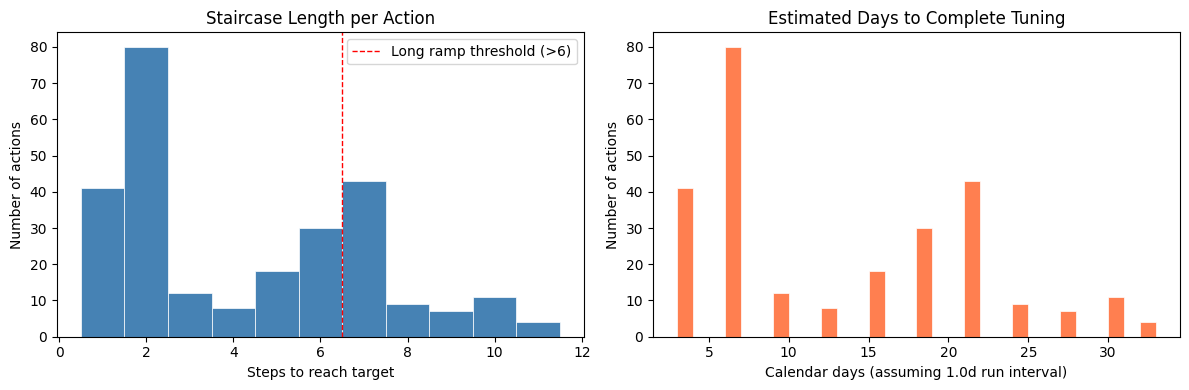


Long ramp actions by config_key:
                              count      mean       std  min  25%  50%  75%   max
config_key                                                                       
clusterMaxWorkers               2.0  7.000000  0.000000  7.0  7.0  7.0  7.0   7.0
spark.driver.memory             2.0  9.000000  0.000000  9.0  9.0  9.0  9.0   9.0
spark.sql.shuffle.partitions   70.0  7.971429  1.351021  7.0  7.0  7.0  9.0  11.0


In [18]:
if len(cycle_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: histogram of steps per action
    axes[0].hist(cycle_df['n_steps'], bins=range(1, cycle_df['n_steps'].max() + 2),
                 color='steelblue', edgecolor='white', linewidth=0.5, align='left')
    axes[0].axvline(x=6.5, color='red', linestyle='--', linewidth=1, label='Long ramp threshold (>6)')
    axes[0].set_xlabel('Steps to reach target')
    axes[0].set_ylabel('Number of actions')
    axes[0].set_title('Staircase Length per Action')
    axes[0].legend()

    # Right: histogram of calendar days to completion
    axes[1].hist(cycle_df['calendar_days'], bins=30,
                 color='coral', edgecolor='white', linewidth=0.5)
    axes[1].set_xlabel(f'Calendar days (assuming {DEFAULT_RUN_INTERVAL_DAYS}d run interval)')
    axes[1].set_ylabel('Number of actions')
    axes[1].set_title('Estimated Days to Complete Tuning')

    plt.tight_layout()
    plt.show()

    print()
    print('Long ramp actions by config_key:')
    print(cycle_df[cycle_df['is_long_ramp']].groupby('config_key')['n_steps'].describe().to_string())
else:
    print('No cycle data to plot.')

### 6a — Why are some ramps so long?

Investigate actions with `n_steps > 6` (the right-hand tail of the histogram).

In [19]:
# Deep-dive: long staircase actions (n_steps > 6)
LONG_RAMP_THRESHOLD = 6

if len(cycle_df) == 0:
    print("Run the cycle_df cell above first.")
else:
    long_df = cycle_df[cycle_df["n_steps"] > LONG_RAMP_THRESHOLD].copy()
    print(f"Long ramps: {len(long_df)} / {len(cycle_df)} actions ({100*len(long_df)/len(cycle_df):.1f}%)\n")

    if len(long_df) == 0:
        print("No long ramps in this dataset.")
    else:
        # --- 1) Which knobs? ---
        print("## By config_key\n")
        print(long_df.groupby("config_key").agg(
            count=("n_steps", "count"),
            n_steps=("n_steps", "first"),
            insight_type=("insight_type", "first"),
        ).to_string())
        print()

        # --- 2) Join plan actions for current → target ---
        long_detail = []
        cap_driver = KNOB_REGISTRY["spark.driver.cores"]
        for _, row in long_df.iterrows():
            task_key = (row["app_id"], row["task_name"])
            ck = row["config_key"]
            plan = plans.get(task_key)
            if not plan:
                continue
            action = next((a for a in plan.actions if a.config_key == ck), None)
            if not action:
                continue
            cur, tgt = action.current_value, action.target_value
            staircase = build_staircase(
                cur, tgt, cap_driver,
                default_constraints.default_step_pct_cap,
                default_constraints.default_step_abs_cap,
            )
            # Per-step drop sizes
            path = [cur] + list(staircase)
            drops = [path[i] - path[i + 1] for i in range(len(path) - 1)]
            long_detail.append({
                **task_meta_dict(task_key, prepared_tasks),
                "config_key": ck,
                "insight_type": row["insight_type"],
                "current": cur,
                "target": tgt,
                "delta": int(cur) - int(tgt) if isinstance(cur, (int, float)) else None,
                "n_steps": row["n_steps"],
                "runs_to_confirm": row["runs_to_confirm"],
                "calendar_days_1d": row["calendar_days"],
                "first_step_drop": drops[0] if drops else None,
                "last_step_drop": drops[-1] if drops else None,
                "staircase_preview": " → ".join(str(int(x)) for x in path[:6]) + " → … → " + str(int(path[-1])),
            })

        detail_df = pd.DataFrame(long_detail)
        if len(detail_df):
            print("## Current → target (all long ramps)\n")
            print(detail_df.drop(columns=["staircase_preview"]).drop_duplicates(
                ["config_key", "current", "target", "n_steps"]
            ).to_string(index=False))
            print("\n## Example staircase (first long action)\n")
            ex = detail_df.iloc[0]
            task_key = (ex['app_id'], ex['task_name'])
            action = next(a for a in plans[task_key].actions if a.config_key == ex["config_key"])
            ramp = [action.current_value] + list(build_staircase(
                action.current_value, action.target_value, cap_driver,
                default_constraints.default_step_pct_cap,
                default_constraints.default_step_abs_cap,
            ))
            print(f"{task_key_label(task_key)}  {ex['config_key']}: {' → '.join(map(str, ramp))}")
            print(f"\nStep cap for spark.driver.cores: pct_cap={cap_driver.pct_cap:.0%}, abs_cap={cap_driver.abs_cap}")
            print(f"At current={ex['current']}, max drop per step = max(abs_cap, current×pct) = "
                  f"max({cap_driver.abs_cap}, {int(ex['current'])*cap_driver.pct_cap:.0f}) = "
                  f"{max(cap_driver.abs_cap, int(ex['current'])*cap_driver.pct_cap):.0f}")

        # --- 3) Payload / CSV context for driver-cores long ramps ---
        if "spark.driver.cores" in long_df["config_key"].values:
            print("\n## Insight payload context (over_provisioned_driver_cores)\n")
            driver_long_keys = set(zip(
                long_df[long_df["config_key"] == "spark.driver.cores"]["app_id"],
                long_df[long_df["config_key"] == "spark.driver.cores"]["task_name"],
            ))
            ins_rows = df_insights[
                df_insights.apply(lambda r: (r["app_id"], r["task_name"]) in driver_long_keys, axis=1)
                & (df_insights["insight_type"] == "over_provisioned_driver_cores")
            ]
            ins_rows = latest_insight_rows_per_task(ins_rows)

            payload_stats = []
            for _, r in ins_rows.iterrows():
                p = parse_insights_payload(r)
                payload_stats.append({
                    "app_id": r.get("app_id"),
                    "task_name": r.get("task_name"),
                    "task_id": r.get("task_id"),
                    "csv_spark_driver_cores": r.get("spark_driver_cores"),
                    "payload_current": p.get("current_driver_cores") if p else None,
                    "payload_suggested": p.get("suggested_driver_cores") if p else None,
                    "has_dedicated_cluster": p.get("has_dedicated_cluster") if p else None,
                })
            ps = pd.DataFrame(payload_stats)
            print(ps.drop_duplicates(
                ["task_name", "payload_current", "payload_suggested", "has_dedicated_cluster"]
            ).to_string(index=False))
            print(f"\nUnique logical tasks: {ps.groupby(TASK_KEY).ngroups}")

        # --- 4) Root-cause summary ---
        print("\n" + "=" * 72)
        print("ROOT CAUSE SUMMARY")
        print("=" * 72)
        if len(detail_df) and detail_df["config_key"].nunique() == 1 and detail_df["current"].nunique() == 1:
            c0, t0 = detail_df["current"].iloc[0], detail_df["target"].iloc[0]
            ns = int(detail_df["n_steps"].iloc[0])
            print(
                f"• All {len(long_df)} long ramps are the SAME recommendation: "
                f"spark.driver.cores {int(c0)} → {int(t0)}.\n"
                f"• Knob registry allows max {cap_driver.pct_cap:.0%} reduction per step "
                f"(or {cap_driver.abs_cap} cores, whichever is larger).\n"
                f"• At {int(c0)} cores, each step drops ~{int(c0)*cap_driver.pct_cap:.0f} cores "
                f"({cap_driver.pct_cap:.0%}), giving a ~{int((1-cap_driver.pct_cap)*100)}% "
                f"multiplicative staircase → {ns} steps to reach {int(t0)}.\n"
                f"• Calendar time assumes {CONFIRMATION_RUNS_REQUIRED} confirming runs per step × "
                f"{DEFAULT_RUN_INTERVAL_DAYS}d interval → "
                f"{ns}×{CONFIRMATION_RUNS_REQUIRED}×{DEFAULT_RUN_INTERVAL_DAYS:.0f} = "
                f"{ns * CONFIRMATION_RUNS_REQUIRED * DEFAULT_RUN_INTERVAL_DAYS:.0f} days.\n"
                f"• These tasks are serverless (has_dedicated_cluster=False); L1 maps the insight to "
                f"spark.driver.cores instead of instance-type change.\n"
                f"• current_driver_cores=256 is suspicious for Spark (typical values are 1–8); "
                f"likely upstream insight/CSV mapping — worth validating before tuning."
            )
        else:
            print("Long ramps span multiple knobs/values — inspect detail_df above.")


Long ramps: 74 / 263 actions (28.1%)

## By config_key

                              count  n_steps                         insight_type
config_key                                                                       
clusterMaxWorkers                 2        7                       long_idle_time
spark.driver.memory               2        9  over_provisioned_driver_heap_memory
spark.sql.shuffle.partitions     70        7                       long_skew_time

## Current → target (all long ramps)

 app_id                                            task_name  task_id                   config_key                        insight_type  current  target  delta  n_steps  runs_to_confirm  calendar_days_1d  first_step_drop  last_step_drop
  12632 web_session_page_sequence_incremental_load_iteration  2035206 spark.sql.shuffle.partitions                      long_skew_time      200     400   -200        7               21              21.0              -50              -1
  21513                

## Cell Group 7 — Phase 3: Blocking Rule Fire Rates

**Business question:** Which blocking rules fire most often, and are any
high-value recommendations being blocked?

For statistical power, all rows with a `config_key` recommendation are included
(not just the latest per task).

The block reason string is parsed to extract the rule name for the summary table.

In [20]:
def _rule_label_from_reason(reason_str):
    """Extract a short rule label from the block_reason text.

    Matches the first distinctive keyword in the block_reason string to one
    of the six named blocking rules.
    """
    if not reason_str:
        return 'unknown'
    r = reason_str.lower()
    if 'spark will ignore' in r or 'auto-optimize shuffle' in r or 'aqe' in r or 'auto\'' in r or 'set to' in r:
        return 'Rule1_AQE_override'
    if 'active spill' in r and ('executor count' in r or 'executor memory' in r or 'reducing executor' in r or 'reducing memory' in r):
        return 'Rule2_spill_capacity'
    if 'gc' in r and ('consuming' in r or 'worsen gc' in r or 'severe' in r or 'reducing memory' in r):
        return 'Rule3_gc_pressure'
    if 'heap memory headroom' in r:
        return 'Rule4a_heap_headroom'
    if 'off-heap memory headroom' in r:
        return 'Rule4b_offheap_headroom'
    if 'vcore utilization' in r or 'cpu-saturated' in r:
        return 'Rule5_vcore_saturation'
    if 'shuffle partitions per executor' in r or 'skew' in r:
        return 'Rule6_skew_partition_ratio'
    return 'other'


# Iterate ALL rows with a usable insight_type (not just latest per task)
df_all_insights = df[
    df['insight_type'].notna() &
    (df['insight_type'].str.strip() != '')
].copy()

rule_applicable = collections.Counter()
rule_blocked    = collections.Counter()

# High value blocked rows: insight_usd_cost > $10k but action is blocked
high_value_blocked = []

for _, row in df_all_insights.iterrows():
    insight_type = str(row.get('insight_type', '')).strip()
    payload = parse_insights_payload(row)
    if not payload:
        continue

    metrics = build_run_metrics(row)
    profile = build_task_profile(row)

    recs = extract_recommendations(insight_type, payload, task_profile=profile)
    if not recs:
        continue

    usd_cost = safe_float(row.get('insight_usd_cost'))

    for rec in recs:
        config_key = rec.get('config_key')
        current = rec.get('current_value')
        target = rec.get('suggested_value')

        rule_applicable['ALL'] += 1
        if config_key:
            rule_applicable[config_key] += 1

        is_blocked, reason = check_blocking(config_key, current, target, profile, metrics)

        if is_blocked:
            rule_label = _rule_label_from_reason(reason)
            rule_blocked['ALL'] += 1
            rule_blocked[rule_label] += 1

            if usd_cost is not None and usd_cost > 10_000:
                high_value_blocked.append({
                    'app_id': row.get('app_id'),
                    'task_name': row.get('task_name'),
                    'task_id': row.get('task_id'),
                    'insight_type': insight_type,
                    'config_key': config_key,
                    'usd_cost': usd_cost,
                    'rule': rule_label,
                    'reason_snippet': str(reason)[:120] if reason else '',
                })

print(f'Total recommendations evaluated: {rule_applicable["ALL"]}')
print(f'Total blocked:                   {rule_blocked["ALL"]}')
if rule_applicable['ALL'] > 0:
    print(f'Overall block rate:              {100 * rule_blocked["ALL"] / rule_applicable["ALL"]:.1f}%')


Total recommendations evaluated: 3037
Total blocked:                   36
Overall block rate:              1.2%


In [21]:
# Summary table: rule | blocked_count | fire_rate
rule_names = [
    'Rule1_AQE_override',
    'Rule2_spill_capacity',
    'Rule3_gc_pressure',
    'Rule4a_heap_headroom',
    'Rule4b_offheap_headroom',
    'Rule5_vcore_saturation',
    'Rule6_skew_partition_ratio',
    'other',
]

total_rec = rule_applicable['ALL'] or 1  # avoid divide-by-zero
rule_summary = []
for rule in rule_names:
    blocked = rule_blocked.get(rule, 0)
    rule_summary.append({
        'rule': rule,
        'blocked_recs': blocked,
        'fire_rate_pct': round(100.0 * blocked / total_rec, 2),
    })

rule_df = pd.DataFrame(rule_summary).sort_values('blocked_recs', ascending=False)
print('Blocking rule fire rates:')
print(rule_df.to_string(index=False))
print()

# Note on signal availability for Rule 3 (GC pressure)
gc_null_count = null_signal_counts.get('gc_pressure', 0)
print(f'Note: gc_pressure signal was unavailable for {gc_null_count} tasks.')
print('  This suppresses Rule3 for those tasks — GC blocking may be underestimated.')
print()
print(f'High-value blocked recommendations (>$10k): {len(high_value_blocked)}')
if high_value_blocked:
    hvb_df = pd.DataFrame(high_value_blocked).sort_values('usd_cost', ascending=False)
    print(hvb_df[['app_id', 'task_name', 'task_id', 'insight_type', 'config_key', 'usd_cost', 'rule']].head(10).to_string(index=False))


Blocking rule fire rates:
                      rule  blocked_recs  fire_rate_pct
      Rule2_spill_capacity            19           0.63
        Rule1_AQE_override            17           0.56
         Rule3_gc_pressure             0           0.00
      Rule4a_heap_headroom             0           0.00
   Rule4b_offheap_headroom             0           0.00
    Rule5_vcore_saturation             0           0.00
Rule6_skew_partition_ratio             0           0.00
                     other             0           0.00

Note: gc_pressure signal was unavailable for 55 tasks.
  This suppresses Rule3 for those tasks — GC blocking may be underestimated.

High-value blocked recommendations (>$10k): 11
 app_id task_name  task_id              insight_type                   config_key     usd_cost               rule
  21689   compute  2052114 executors_long_spill_time spark.sql.shuffle.partitions 16106.777641 Rule1_AQE_override
  21689   compute  2051400 executors_long_spill_time spark.sq

## Cell Group 8 — Phase 4: Duration Regression False-Positive Rate

**Business question:** How often does the duration regression detector raise a
false alarm on a task where nothing actually changed?

**Data limitation:** The CSV contains one row per `(task_id, insight_type)` run
snapshot, not a full time series keyed by logical task.  Many rows share the same
`(app_id, task_name)` across different `task_id` values (historical runs).  Rows
with ≥3 entries for one `task_id` are different insight types on the same run,
not multiple runs.

The false-positive simulation therefore uses **synthetic duration series** derived
from the measured `task_duration_seconds` distribution (sampled from real values,
one sample per logical task) to give statistically meaningful results.


In [22]:
import random
random.seed(42)

# ── Data availability check ──────────────────────────────────────────────────
logical_task_run_counts = df.groupby(TASK_KEY)['task_id'].nunique()
tasks_ge3_runs = logical_task_run_counts[logical_task_run_counts >= 3].index
tasks_ge5_runs = logical_task_run_counts[logical_task_run_counts >= 5].index

print(f'Logical tasks with >=3 distinct runs (task_id): {len(tasks_ge3_runs)}')
print(f'Logical tasks with >=5 distinct runs (task_id): {len(tasks_ge5_runs)}')
print()
print('NOTE: Rows sharing one task_id with multiple insight_types are one run,')
print('not a multi-insight time series.  Count runs by (app_id, task_name).')
print('The false-positive simulation below uses synthetic stable duration series.')


Logical tasks with >=3 distinct runs (task_id): 1176
Logical tasks with >=5 distinct runs (task_id): 469

NOTE: Rows sharing one task_id with multiple insight_types are one run,
not a multi-insight time series.  Count runs by (app_id, task_name).
The false-positive simulation below uses synthetic stable duration series.


In [23]:
# ── Synthetic false-positive simulation ──────────────────────────────────────
#
# One sample per logical task (app_id + task_name): latest row with duration.
# Simulate stable 8-run history with ±10% Gaussian noise around measured value.

valid_tasks = df[df['task_duration_seconds'].notna() & (df['task_duration_seconds'] > 0)].copy()
valid_tasks = latest_run_row_per_task(valid_tasks)
sample_tasks = valid_tasks.sample(min(500, len(valid_tasks)), random_state=42)

NOISE_LEVEL = 0.10
N_BASELINE  = 5
N_TEST      = 3
PRESETS     = ['strict', 'standard', 'flexible']

fp_counts = {p: 0 for p in PRESETS}
total_tests = 0

for _, task_row in sample_tasks.iterrows():
    base_duration = float(task_row['task_duration_seconds']) * 1000

    def _jittered():
        noise = random.gauss(0, NOISE_LEVEL * base_duration)
        return max(1.0, base_duration + noise)

    all_runs = [_jittered() for _ in range(N_BASELINE + N_TEST)]
    baseline = all_runs[:N_BASELINE]
    test_runs = all_runs[N_BASELINE:]

    for preset in PRESETS:
        for run_dur in test_runs:
            assessment = assess_duration_regression(
                run_duration_ms=run_dur,
                baseline_durations_ms=baseline,
                tolerance_preset=preset,
            )
            if assessment.is_regression:
                fp_counts[preset] += 1
    total_tests += N_TEST

print(f'Simulated logical tasks: {len(sample_tasks)}')
print(f'Test runs per preset: {total_tests}')
print()
print('False-positive rate by tolerance preset (stable tasks, nothing changed):')
for preset in PRESETS:
    fp_rate = 100.0 * fp_counts[preset] / total_tests if total_tests else 0
    print(f'  {preset:<10}: {fp_counts[preset]:>4} / {total_tests}  ({fp_rate:.2f}%)')

print()
print('Expected: strict > standard > flexible (higher threshold = fewer false positives)')
print('CAVEAT: Results are based on synthetic Gaussian noise, not real multi-run data.')


Simulated logical tasks: 500
Test runs per preset: 1500

False-positive rate by tolerance preset (stable tasks, nothing changed):
  strict    :  244 / 1500  (16.27%)
  standard  :  163 / 1500  (10.87%)
  flexible  :  103 / 1500  (6.87%)

Expected: strict > standard > flexible (higher threshold = fewer false positives)
CAVEAT: Results are based on synthetic Gaussian noise, not real multi-run data.


In [24]:
# ── Confirmation window simulation ───────────────────────────────────────────
#
# Simulate get_confirmation_status on stable tasks: how often does a task
# that is genuinely stable FAIL confirmation (all 3 runs at target must pass)?

def _simulate_confirmation_fp(n_sim=500, noise_level=0.10, seed=42):
    random.seed(seed)
    fails = {p: 0 for p in PRESETS}

    for task_row in sample_tasks.itertuples():
        base_dur = float(task_row.task_duration_seconds) * 1000  # ms

        def _jit():
            return max(1.0, base_dur + random.gauss(0, noise_level * base_dur))

        # 5 baseline + 3 confirmation runs, all at 'target' config (no real change)
        all_runs = [_jit() for _ in range(8)]
        baseline = all_runs[:5]
        confirm_runs = all_runs[5:]
        target_value = 10.0   # arbitrary; all runs are at this value

        # Compute z-scores for confirmation runs
        for preset in PRESETS:
            from app.brain.insights.tuning.run_assessor import _REGRESSION_Z_THRESHOLDS
            z_threshold = _REGRESSION_Z_THRESHOLDS[preset]
            run_config_values = [target_value] * 3
            run_z_scores = []
            for r in confirm_runs:
                a = assess_duration_regression(
                    run_duration_ms=r,
                    baseline_durations_ms=baseline,
                    tolerance_preset=preset,
                )
                run_z_scores.append(a.z_score)

            status = get_confirmation_status(
                run_config_values=run_config_values,
                run_z_scores=run_z_scores,
                target_value=target_value,
                regression_z_threshold=z_threshold,
            )
            if not status.confirmed:
                fails[preset] += 1

    return fails


conf_fails = _simulate_confirmation_fp()
n_sim = len(sample_tasks)
print(f'Confirmation window false-failure rate (stable tasks should confirm):')
for preset in PRESETS:
    rate = 100.0 * conf_fails[preset] / n_sim if n_sim else 0
    print(f'  {preset:<10}: failed {conf_fails[preset]:>4} / {n_sim}  ({rate:.1f}% failure rate)')
print()
print('A stable task FAILS confirmation when any of its 3 post-change runs is')
print('flagged as a regression — this keeps the tuning window unnecessarily open.')

Confirmation window false-failure rate (stable tasks should confirm):
  strict    : failed  191 / 500  (38.2% failure rate)
  standard  : failed  132 / 500  (26.4% failure rate)
  flexible  : failed   86 / 500  (17.2% failure rate)

A stable task FAILS confirmation when any of its 3 post-change runs is
flagged as a regression — this keeps the tuning window unnecessarily open.


## Cell Group 9 — Phase 5: Edge Cases

Five targeted checks for scenarios that could produce incorrect recommendations,
silent no-ops, or arithmetic errors.

### 5a — High-Value Fully Blocked Tasks

In [25]:
# Tasks where ALL actions are blocked but total blocked savings > $5k
HIGH_VALUE_BLOCKED_THRESHOLD = 5_000

fully_blocked_hv = []
for task_key, plan in plans.items():
    if plan.actions:
        continue  # has at least one unblocked action
    total_blocked_savings = sum(
        (a.cost_savings_usd_annual or 0.0) for a in plan.blocked_actions
    )
    if total_blocked_savings > HIGH_VALUE_BLOCKED_THRESHOLD:
        fully_blocked_hv.append({
            **task_meta_dict(task_key, prepared_tasks),
            'blocked_savings_usd': total_blocked_savings,
            'n_blocked_actions': len(plan.blocked_actions),
            'block_reasons': '; '.join(
                (_rule_label_from_reason(a.block_reason)) for a in plan.blocked_actions
            ),
            'insight_types': ', '.join(plan.active_insight_types),
        })

fully_blocked_hv.sort(key=lambda x: -x['blocked_savings_usd'])
print(f'Fully blocked tasks with >${HIGH_VALUE_BLOCKED_THRESHOLD:,} blocked savings: {len(fully_blocked_hv)}')
if fully_blocked_hv:
    print()
    hvb_df2 = pd.DataFrame(fully_blocked_hv)
    print(hvb_df2.head(10).to_string(index=False))


Fully blocked tasks with >$5,000 blocked savings: 1

 app_id task_name  task_id  blocked_savings_usd  n_blocked_actions      block_reasons             insight_types
  21689   compute  2052114         16106.777641                  1 Rule1_AQE_override executors_long_spill_time


### 5b — Long Staircases

In [26]:
# Actions where n_steps > 6, and calendar days at two assumed run frequencies
LONG_STAIRCASE_THRESHOLD = 6

if len(cycle_df) > 0:
    long_df = cycle_df[cycle_df['n_steps'] > LONG_STAIRCASE_THRESHOLD].copy()
    print(f'Actions with >6 steps: {len(long_df)}')
    if len(long_df) > 0:
        long_df['days_daily'] = long_df['n_steps'] * CONFIRMATION_RUNS_REQUIRED * 1.0
        long_df['days_weekly'] = long_df['n_steps'] * CONFIRMATION_RUNS_REQUIRED * 7.0
        print()
        print('Summary stats for long-staircase actions:')
        print(long_df[['n_steps', 'days_daily', 'days_weekly']].describe().to_string())
        print()
        print('Top long-staircase actions (by n_steps):')
        print(
            long_df[TASK_KEY + ['task_id', 'config_key', 'insight_type', 'n_steps', 'days_daily', 'days_weekly']]
            .sort_values('n_steps', ascending=False)
            .head(10)
            .to_string(index=False)
        )
else:
    print('No cycle data available for staircase analysis.')


Actions with >6 steps: 74

Summary stats for long-staircase actions:
         n_steps  days_daily  days_weekly
count  74.000000   74.000000    74.000000
mean    7.972973   23.918919   167.432432
std     1.334197    4.002591    28.018136
min     7.000000   21.000000   147.000000
25%     7.000000   21.000000   147.000000
50%     7.000000   21.000000   147.000000
75%     9.000000   27.000000   189.000000
max    11.000000   33.000000   231.000000

Top long-staircase actions (by n_steps):
 app_id                                                      task_name  task_id                   config_key              insight_type  n_steps  days_daily  days_weekly
   1279                                      Build_UTM_Attributes_SCD2  2046475 spark.sql.shuffle.partitions executors_long_spill_time       11        33.0        231.0
   6622                                   warehouse_web_ui_interaction  2047081 spark.sql.shuffle.partitions            long_skew_time       11        33.0        231.0
   1

### 5c — Multi-Insight Config Key Conflicts

In [27]:
# Tasks with multiple insight_types: check for actions targeting the same config_key
# in conflicting directions (one wants to increase, another wants to decrease)

def _direction(current, target):
    """Return 'decrease', 'increase', 'same', or 'unknown'."""
    try:
        c, t = float(current), float(target)
        if t < c: return 'decrease'
        if t > c: return 'increase'
        return 'same'
    except (TypeError, ValueError):
        return 'unknown'


conflicts = []
for task_key, plan in plans.items():
    if len(plan.active_insight_types) < 2:
        continue  # only one insight type — no conflict possible

    # Build map: config_key -> list of (direction, insight_type)
    key_directions = collections.defaultdict(list)
    for action in plan.actions + plan.blocked_actions:
        if not action.config_key:
            continue
        d = _direction(action.current_value, action.target_value)
        if d in ('increase', 'decrease'):
            key_directions[action.config_key].append((d, action.insight_type))

    for config_key, entries in key_directions.items():
        directions = {e[0] for e in entries}
        if len(directions) > 1:  # both 'increase' and 'decrease' for same key
            conflicts.append({
                **task_meta_dict(task_key, prepared_tasks),
                'config_key': config_key,
                'conflict_details': str(entries),
            })

print(f'Tasks with multi-insight config key conflicts: {len(conflicts)}')
if conflicts:
    print()
    conflict_df = pd.DataFrame(conflicts)
    print(conflict_df.head(10).to_string(index=False))
else:
    print('No conflicting recommendations found — the framework correctly deduplicates')
    print('or the insight types in this dataset target different config keys.')


Tasks with multi-insight config key conflicts: 0
No conflicting recommendations found — the framework correctly deduplicates
or the insight types in this dataset target different config keys.


### 5d — Numeric Edge Cases in Step Math

In [28]:
# Find rows where current_value == 1 (can't reduce further) or extremely large (> 1e6)
# and verify the staircase math doesn't break

edge_case_results = []

for task_key, plan in plans.items():
    for action in plan.actions + plan.blocked_actions:
        current = action.current_value
        target  = action.target_value
        if not isinstance(current, (int, float)) or not isinstance(target, (int, float)):
            continue

        is_edge = False
        edge_label = ''
        if current == 1 and target < current:
            is_edge = True
            edge_label = 'current==1_cant_reduce'
        elif abs(current) > 1e6:
            is_edge = True
            edge_label = 'current_very_large'
        elif abs(target) > 1e6:
            is_edge = True
            edge_label = 'target_very_large'

        if not is_edge:
            continue

        # Test staircase
        reg_key = registry_key_for_rec({'config_key': action.config_key, 'action': action.action})
        cap = KNOB_REGISTRY.get(reg_key, DEFAULT_CAP)
        try:
            staircase = build_staircase(
                current, target, cap,
                default_constraints.default_step_pct_cap,
                default_constraints.default_step_abs_cap,
            )
            error = None
            n_steps = len(staircase)
        except Exception as exc:
            error = str(exc)
            n_steps = -1

        edge_case_results.append({
            **task_meta_dict(task_key, prepared_tasks),
            'config_key': action.config_key,
            'current': current,
            'target': target,
            'edge_label': edge_label,
            'n_steps': n_steps,
            'error': error,
        })

print(f'Numeric edge-case actions found: {len(edge_case_results)}')
if edge_case_results:
    edge_df = pd.DataFrame(edge_case_results)
    print(edge_df.to_string(index=False))
    errors = [r for r in edge_case_results if r['error']]
    if errors:
        print()
        print(f'ERRORS in staircase computation: {len(errors)}')
        for e in errors:
            print(f'  task={task_key_label((e["app_id"], e["task_name"]))} key={e["config_key"]} error={e["error"]}')
    else:
        print()
        print('No errors — staircase handles all numeric edge cases gracefully.')
else:
    print('No edge cases found in this dataset.')


Numeric edge-case actions found: 0
No edge cases found in this dataset.


### 5e — Missing Extractors (Orphaned Insight Types)

In [29]:
# Count rows per insight_type where extract_recommendations returns [] (no extractor)
# These are 'orphaned' insight types — the framework has no automation path for them.

# Known extractors as of the codebase scan
KNOWN_EXTRACTORS = {
    'over_provisioned_executors',
    'over_provisioned_cluster_machines',
    'over_provisioned_executor_heap_memory',
    'over_provisioned_executor_off_heap_memory',
    'over_provisioned_driver_cores',
    'over_provisioned_driver_heap_memory',
    'over_provisioned_machine_type',
    'executors_long_spill_time',
    'under_utilized_executors_cpu',
    'spark_task_retries_cost',
    'orphaned_machine_vcores',
    'orphaned_node_resources',          # added: emits clusterWorkers/clusterMaxWorkers reduction
    'under_provisioned_executor_heap_memory',
    'executors_long_gc_time',
    'task_retries_cost',                # extractor exists but returns []
    'long_idle_time',                   # emits executor/cluster count reduction when task_profile supplied
    'long_skew_time',                   # emits shuffle.partitions x2 when task_profile has fixed count
    'small_files',                      # extractor exists but returns []
    'stale_task_runs',                  # extractor exists but returns []
    'excessive_listing_operation',      # extractor exists but returns []
}

# Extractors that require task_profile context to produce recommendations
_NEEDS_PROFILE = frozenset({'long_idle_time', 'long_skew_time'})

# Insight types present in this dataset
insight_type_counts = df[
    df['insight_type'].notna() & (df['insight_type'].str.strip() != '')
]['insight_type'].value_counts()

orphan_results = []

for insight_type, count in insight_type_counts.items():
    insight_type = str(insight_type).strip()

    sample_rows = df[df['insight_type'] == insight_type]

    # Check if any payload produces a recommendation.
    # For insight types that require task_profile (e.g. long_idle_time), pair each
    # payload with the matching profile from prepared_tasks when available so the
    # extractor has the executor-count context it needs.
    any_rec = False
    no_payload = True

    for _, row in sample_rows.head(20).iterrows():
        payload = parse_insights_payload(row)
        if payload is None:
            continue
        no_payload = False
        task_key = task_key_from_row(row)
        profile = (
            prepared_tasks.get(task_key, {}).get('profile')
            if insight_type in _NEEDS_PROFILE
            else None
        )
        recs = extract_recommendations(insight_type, payload, task_profile=profile)
        if recs:
            any_rec = True
            break

    if no_payload:
        orphan_results.append({
            'insight_type': insight_type,
            'row_count': count,
            'has_extractor': insight_type in KNOWN_EXTRACTORS,
            'extractor_produces_recs': False,
            'note': 'no payload available to test',
        })
        continue

    note = ''
    if not any_rec:
        if insight_type in _NEEDS_PROFILE:
            note = 'requires task_profile — no matching profile found in sample rows'
        else:
            note = 'extractor returns [] for all sampled payloads'

    orphan_results.append({
        'insight_type': insight_type,
        'row_count': count,
        'has_extractor': insight_type in KNOWN_EXTRACTORS,
        'extractor_produces_recs': any_rec,
        'note': note,
    })

orphan_df = pd.DataFrame(orphan_results).sort_values('row_count', ascending=False)
print('Extractor coverage by insight type:')
print(orphan_df.to_string(index=False))
print()

no_extractor = orphan_df[~orphan_df['has_extractor']]
no_recs_despite_extractor = orphan_df[orphan_df['has_extractor'] & ~orphan_df['extractor_produces_recs']]

if len(no_extractor) > 0:
    print('Insight types with NO extractor registered:')
    for _, r in no_extractor.iterrows():
        print(f'  {r["insight_type"]} ({r["row_count"]} rows)')
    print()

if len(no_recs_despite_extractor) > 0:
    print('Insight types WITH extractor but returning [] for all tested payloads:')
    for _, r in no_recs_despite_extractor.iterrows():
        print(f'  {r["insight_type"]} ({r["row_count"]} rows) — {r["note"]}')


Extractor coverage by insight type:
                             insight_type  row_count  has_extractor  extractor_produces_recs                                          note
                           long_skew_time        907           True                     True                                              
                           long_idle_time        875           True                     True                                              
                  orphaned_machine_vcores        691           True                     True                                              
            over_provisioned_driver_cores        681           True                     True                                              
                        task_retries_cost        357           True                    False extractor returns [] for all sampled payloads
                  orphaned_node_resources        291           True                    False extractor returns [] for all sampled 

## Cell Group 10 — Autonomous Loop: Real-Data Simulation

End-to-end simulation of the `loop.py` state machine against real tasks from the
dataset.  No actual job runs are executed — each "run" is simulated with stable
performance (no regression, no failure, no cost increase) to show the expected
happy-path cycle count and decision sequence.

**What this section measures**

| Cell | Question |
|------|----------|
| 46 | Session length distribution — total job runs per task to complete all knobs |
| 47 | First-run decision preview — what action does the loop recommend after run 1? |
| 48 | Full session walkthrough — step-by-step log for the top 5 tasks by savings |

**Assumptions (happy-path simulation)**
- Each synthetic run succeeds (`job_status="success"`).
- Cost is constant ($10/run) — never triggers the *abandon* rule.
- Duration equals the task's measured `task_duration_seconds` ± 10% Gaussian noise —
  well below the regression z-score threshold with a 5-run baseline.


Per-action session length  (search steps + 3 confirmation runs):
# actions    263.000000
mean runs      7.292776
std            2.840853
min            4.000000
p25            5.000000
median         6.000000
p75           10.000000
max           14.000000

Per-task session length  (all knobs summed):
# tasks      224.000000
mean runs      8.562500
std            4.386652
min            4.000000
p25            5.000000
median         8.000000
p75           10.000000
max           30.000000

Calendar days at 1 run/day — median 8d, p75 10d, max 30d


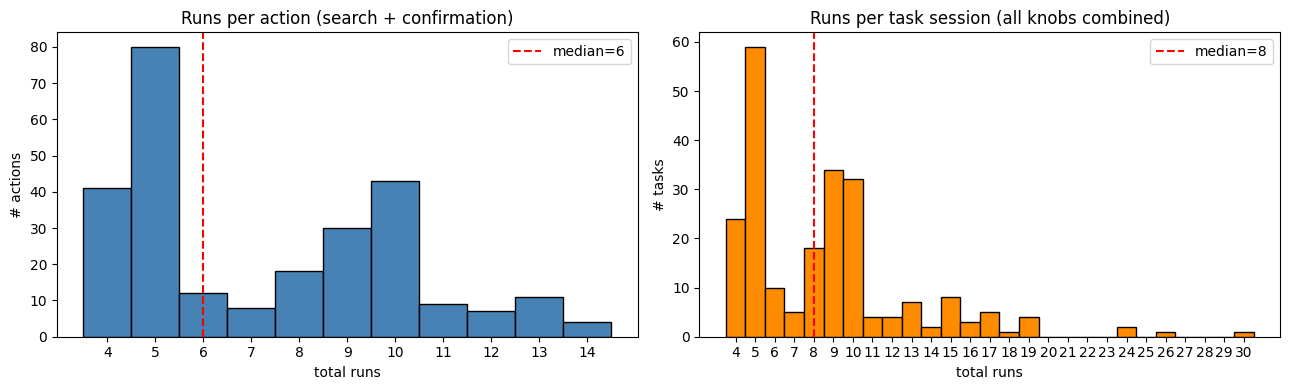

In [30]:
# Session length = total job runs to complete all knobs for a task.
# Each knob needs:  len(staircase) search runs + CONFIRMATION_RUNS_REQUIRED confirmation runs.
#
# cycle_df (from Group 6) already has n_steps per unblocked action.  We add the
# confirmation window and aggregate per task.

# Imports available here because cell 3 was run first
from app.brain.insights.tuning import (
    create_knob_state, get_initial_next_value, process_run_outcome,
    RunOutcome, KnobTuningState, TaskTuningSession,
)

if 'cycle_df' not in dir() or len(cycle_df) == 0:
    print("Run Group 6 first to build cycle_df.")
else:
    cycle_df2 = cycle_df.copy()
    cycle_df2['total_runs'] = cycle_df2['n_steps'] + CONFIRMATION_RUNS_REQUIRED

    # Sum across all knobs per task
    task_total_runs = cycle_df2.groupby(TASK_KEY)['total_runs'].sum()

    print(f'Per-action session length  (search steps + {CONFIRMATION_RUNS_REQUIRED} confirmation runs):')
    print(cycle_df2['total_runs'].describe().rename({
        'count': '# actions', 'mean': 'mean runs', 'std': 'std',
        'min': 'min', '25%': 'p25', '50%': 'median', '75%': 'p75', 'max': 'max',
    }).to_string())
    print()
    print(f'Per-task session length  (all knobs summed):')
    print(task_total_runs.describe().rename({
        'count': '# tasks', 'mean': 'mean runs', 'std': 'std',
        'min': 'min', '25%': 'p25', '50%': 'median', '75%': 'p75', 'max': 'max',
    }).to_string())
    print()
    print(f'Calendar days at 1 run/day — median {task_total_runs.median():.0f}d, p75 {task_total_runs.quantile(0.75):.0f}d, max {task_total_runs.max():.0f}d')

    def _plot_integer_histogram(ax, values, title, ylabel, color):
        """Histogram with bins centered on integers so the median line aligns with bars."""
        values = pd.Series(values).astype(int)
        lo, hi = int(values.min()), int(values.max())
        bins = [x - 0.5 for x in range(lo, hi + 2)]
        ax.hist(values, bins=bins, edgecolor='black', color=color)
        median = values.median()
        ax.axvline(median, color='red', linestyle='--', label=f'median={median:.0f}')
        ax.set_title(title)
        ax.set_xlabel('total runs')
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(lo, hi + 1))
        ax.legend()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    _plot_integer_histogram(
        axes[0],
        cycle_df2['total_runs'],
        'Runs per action (search + confirmation)',
        '# actions',
        'steelblue',
    )
    _plot_integer_histogram(
        axes[1],
        task_total_runs,
        'Runs per task session (all knobs combined)',
        '# tasks',
        'darkorange',
    )

    plt.tight_layout()
    plt.show()


In [31]:
# Build a TaskTuningSession for every logical task with at least one unblocked action.
# Simulate the first run with stable performance and report what the loop decides.

import random as _rand
import statistics as _stats

def _synthetic_baseline(base_duration_s, n=5, noise_pct=0.10, seed=42):
    '''n stable baseline durations around base_duration_s (seconds to ms).'''
    rng = _rand.Random(seed)
    base_ms = float(base_duration_s) * 1000.0
    return [max(1.0, base_ms + rng.gauss(0, noise_pct * base_ms)) for _ in range(n)]

# Measured duration per logical task from the CSV (seconds) — latest run
_duration_rows = latest_run_row_per_task(
    df[df['task_duration_seconds'].notna() & (df['task_duration_seconds'] > 0)]
)
task_duration_map = {
    (row['app_id'], row['task_name']): float(row['task_duration_seconds'])
    for _, row in _duration_rows.iterrows()
}

loop_sessions = {}   # (app_id, task_name) → TaskTuningSession
first_run_rows = []

for task_key, plan in plans.items():
    if not plan.actions:
        continue

    base_dur_s = task_duration_map.get(task_key)
    baseline_ms = _synthetic_baseline(base_dur_s) if base_dur_s else []
    latest_task_id = prepared_tasks[task_key]['task_id']

    knob_states = {}
    for action in plan.actions:
        if action.current_value is None or action.target_value is None:
            continue
        key = action.config_key or f'__{action.action}__'
        state = create_knob_state(
            config_key=key,
            current_value=action.current_value,
            target_value=action.target_value,
            pre_tuning_durations_ms=baseline_ms,
        )
        knob_states[key] = state

    if not knob_states:
        continue

    session = TaskTuningSession(task_id=latest_task_id, knob_states=knob_states)
    loop_sessions[task_key] = session

    for key, state in session.knob_states.items():
        first_val = get_initial_next_value(state)
        stable_ms = float(base_dur_s or 1.0) * 1000.0
        outcome = RunOutcome(
            applied_value=first_val,
            job_status='success',
            run_cost_usd=10.0,
            run_duration_ms=stable_ms,
        )
        _, decision = process_run_outcome(state, outcome)
        first_run_rows.append({
            **task_meta_dict(task_key, prepared_tasks),
            'config_key':       key,
            'initial_value':    state.initial_value,
            'first_applied':    first_val,
            'target_value':     state.target_value,
            'staircase_len':    len(state.staircase) + 1,
            'first_decision':   decision.next_action,
            'phase_after':      decision.updated_phase,
        })

fd_df = pd.DataFrame(first_run_rows)
print(f'Sessions initialised: {len(loop_sessions)}')
print(f'Total knobs across all sessions: {len(fd_df)}')
print()
print('Decision after run 1 (happy-path, stable performance):')
print(fd_df['first_decision'].value_counts().to_string())
print()
print('Phase after run 1:')
print(fd_df['phase_after'].value_counts().to_string())
print()
print('Knobs that land at target on the very first run (single-step or tiny gap):')
at_target = fd_df[fd_df['phase_after'] == 'confirming']
print(f'  {len(at_target)} / {len(fd_df)} knobs  ({100*len(at_target)/max(1,len(fd_df)):.1f}%)')


TypeError: TaskTuningSession.__init__() got an unexpected keyword argument 'task_id'. Did you mean 'task_key'?

In [ ]:
# Full happy-path simulation for the top N logical tasks by estimated annual savings.

MAX_TASKS = 5
MAX_RUNS_PER_KNOB = 60

if 'savings_df' in dir() and len(savings_df) > 0:
    task_savings_totals = savings_df.groupby(TASK_KEY)['full_savings'].sum()
    top_task_keys = list(task_savings_totals.nlargest(MAX_TASKS).index)
else:
    top_task_keys = list(plans.keys())[:MAX_TASKS]

for task_key in top_task_keys:
    plan = plans.get(task_key)
    if plan is None or not plan.actions:
        continue

    base_dur_s = task_duration_map.get(task_key)
    baseline_ms = _synthetic_baseline(base_dur_s) if base_dur_s else []
    stable_ms = float(base_dur_s or 1.0) * 1000.0

    ann = (task_savings_totals.get(task_key, 0) if 'savings_df' in dir() else 0)
    meta = task_meta_dict(task_key, prepared_tasks)
    print(f'\n{"═"*70}')
    print(f'{task_key_label(task_key)}  task_id={meta["task_id"]}  savings ≈ ${ann:,.0f}/yr  {len(plan.actions)} knob(s)')

    session_runs = 0

    for action in plan.actions:
        if action.current_value is None or action.target_value is None:
            continue
        key = action.config_key or f'__{action.action}__'

        state = create_knob_state(
            config_key=key,
            current_value=action.current_value,
            target_value=action.target_value,
            pre_tuning_durations_ms=baseline_ms,
        )

        next_val = get_initial_next_value(state)
        knob_runs = 0

        print(f'\n  [{key}]')
        print(f'  {action.current_value!r}  →  {action.target_value!r}')
        print(f'  staircase: {state.staircase}')
        print()

        while state.phase not in ('completed', 'abandoned') and knob_runs < MAX_RUNS_PER_KNOB:
            outcome = RunOutcome(
                applied_value=next_val,
                job_status='success',
                run_cost_usd=10.0,
                run_duration_ms=stable_ms,
            )
            _, decision = process_run_outcome(state, outcome)
            knob_runs += 1
            phase_icon = {'search': '→', 'confirming': '✓', 'completed': '★', 'abandoned': '✗', 'paused': '⏸'}.get(decision.updated_phase, '?')
            print(f'    run {knob_runs:>2}  apply={str(next_val):>12}  {decision.next_action:<10} {phase_icon} {decision.updated_phase}')
            next_val = decision.next_value

        if knob_runs >= MAX_RUNS_PER_KNOB:
            print(f'  ⚠ safety stop at {MAX_RUNS_PER_KNOB} runs (phase={state.phase})')
        elif state.phase == 'completed':
            print(f'  ✓ complete in {knob_runs} runs')
        elif state.phase == 'abandoned':
            print(f'  ✗ abandoned after {knob_runs} runs')

        session_runs += knob_runs

    print(f'\n  Session total: {session_runs} run(s) across {len(plan.actions)} knob(s)')
